In [45]:
import os
from pathlib import Path
from dataclasses import dataclass
from itertools import combinations
import json

from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import MDAnalysis as mda
from MDAnalysis.analysis import rms, align, diffusionmap
from MDAnalysis.analysis.dihedrals import Janin

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans, HDBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.stats import norm, ttest_ind
from scipy import cluster
from scipy.spatial.distance import squareform


from pymol_utils import write_view_system_frame_pml
from stats_utils import statistical_inefficiency_reworked, effective_sample_size_from_g, sem_from_chodera_reworked, ci_from_chodera_reworked, autocorrelation_time, effective_sample_size, bootstrap_confidence_interval
from trajectory_hull_class import ConvexHullFrame, Trajectory
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Residues implicated in docking poses, 

BINDING_SITE_RESIDUES_onlyRahimova2018 = [
    (366, "A"), (456, "B"), (543, "A"), (543, "B"),                                         # Major H-bond ints in top hits, Fig 6 Rahimova 2018 and text  
    (473, "A"), (473, "B"), (545, "A"), (545, "B"), (471, "A"),                             # Charged residues with non bonding ints, described in text
    (455, "A"), (542, "A"),                                                                 # H-bond ints in Fig 6 with RR6, RR4
    (453, "A"), (453, "B"), (454, "A"), (454, "B"), (544, "A"), (544, "B"),                 # Glycines hydrophobic described in text, Fig 7
]

BINDING_SITE_RESIDUES = [
    (366, "A"), (456, "B"), (543, "A"), (543, "B"), (484, "A"), (484, "B"), (547, "B"),     # Major H-bond ints in top hits, Fig 6 Rahimova 2018 and text  
    (473, "A"), (473, "B"), (545, "A"), (545, "B"), (471, "A"),                             # Charged residues with non bonding ints, described in text
    (455, "A"), (542, "A"),                                                                 # H-bond ints in Fig 6 with RR6, RR4
    (453, "A"), (453, "B"), (454, "A"), (454, "B"), (544, "A"), (544, "B"),                 # Glycines hydrophobic described in text, Fig 7
    (366, "A"), (531, "A"),                                                                 # D366 makes H-bond, Y531 Pi-stack (Grosjean 2025)    
]

# All residues on C-terminal domain interface selected in PyMol through (4 Angstrom A-B chain distance)
# select C_A, (frame_0 and chain A and resi 337-549)
# select C_B, (frame_0 and chain B and resi 337-549)
# select ifaceA, byres (C_A within 4.0 of C_B)
# select ifaceB, byres (C_B within 4.0 of C_A)

# INTERFACE_RESIDUES_5ANGSTROM = [
#     (343, 'A'), (344, 'A'), (345, 'A'), (346, 'A'), (347, 'A'), (352, 'A'), (358, 'A'), 
#     (359, 'A'), (366, 'A'), (369, 'A'), (370, 'A'), (373, 'A'), (374, 'A'), (375, 'A'), 
#     (376, 'A'), (380, 'A'), (381, 'A'), (382, 'A'), (400, 'A'), (456, 'A'), (475, 'A'), 
#     (480, 'A'), (481, 'A'), (482, 'A'), (483, 'A'), (484, 'A'), (531, 'A'), (534, 'A'), 
#     (535, 'A'), (536, 'A'), (537, 'A'), (539, 'A'), (540, 'A'), (541, 'A'), (542, 'A'), 
#     (543, 'A'), (544, 'A'), (547, 'A'), 
#     (343, 'B'), (344, 'B'), (345, 'B'), (347, 'B'), (352, 'B'), (358, 'B'), (359, 'B'), 
#     (366, 'B'), (369, 'B'), (370, 'B'), (373, 'B'), (374, 'B'), (376, 'B'), (380, 'B'), 
#     (381, 'B'), (382, 'B'), (400, 'B'), (403, 'B'), (456, 'B'), (471, 'B'), (473, 'B'), 
#     (475, 'B'), (479, 'B'), (480, 'B'), (481, 'B'), (482, 'B'), (483, 'B'), (484, 'B'), 
#     (531, 'B'), (534, 'B'), (535, 'B'), (536, 'B'), (537, 'B'), (539, 'B'), (540, 'B'), 
#     (541, 'B'), (542, 'B'), (543, 'B'), (544, 'B'), (547, 'B')]

INTERFACE_RESIDUES = [
    (343, 'A'), (344, 'A'), (345, 'A'), (347, 'A'), (359, 'A'), (366, 'A'), (369, 'A'), 
    (370, 'A'), (373, 'A'), (381, 'A'), (382, 'A'), (400, 'A'), (456, 'A'), (475, 'A'), 
    (480, 'A'), (481, 'A'), (482, 'A'), (483, 'A'), (484, 'A'), (535, 'A'), (536, 'A'), 
    (537, 'A'), (539, 'A'), (540, 'A'), (541, 'A'), (542, 'A'), (543, 'A'), (544, 'A'), 
    (547, 'A'), 
    (343, 'B'), (344, 'B'), (345, 'B'), (347, 'B'), (359, 'B'), (366, 'B'), (369, 'B'), 
    (370, 'B'), (373, 'B'), (381, 'B'), (382, 'B'), (400, 'B'), (456, 'B'), (471, 'B'), 
    (475, 'B'), (480, 'B'), (481, 'B'), (482, 'B'), (483, 'B'), (484, 'B'), (534, 'B'), 
    (537, 'B'), (539, 'B'), (540, 'B'), (541, 'B'), (542, 'B'), (543, 'B'), (547, 'B')
]



In [3]:
CWD = Path(os.getcwd()).parent

paths = {
    '4h2i': CWD / '4h2i' / 'unbiased',
    '4h2i_noadn': CWD / '4h2i_noadn' / 'unbiased',
    '4h2g': CWD / '4h2g' / 'unbiased',
    '4h2g_noadn': CWD / '4h2g_noadn' / 'unbiased',
    '6tve': CWD / '6tve' / 'unbiased',
    '6twa': CWD / '6twa' / 'unbiased',
}

allosteric_bindingsite_trajectories = {
        "4h2i": Trajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2i_noadn": Trajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2g": Trajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2g_noadn": Trajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "6tve": Trajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "6twa": Trajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", BINDING_SITE_RESIDUES)
}

allosteric_bindingsite_trajectories_oldselection = {
        "4h2i": Trajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2i_noadn": Trajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2g": Trajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2g_noadn": Trajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "6tve": Trajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "6twa": Trajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018)
}

interface_trajectories = {
        "4h2i": Trajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2i_noadn": Trajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2g": Trajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2g_noadn": Trajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", INTERFACE_RESIDUES),
        "6tve": Trajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", INTERFACE_RESIDUES),
        "6twa": Trajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", INTERFACE_RESIDUES)
}

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


## Binding site residue selection

Binding site residues were chosen based on Figures and docking pose / SAR analyses found in the three papers from the Peyrottes group at the Univ. of Montpellier: 
1. Rahimova 2018 (doi.org/10.1371/journal.pcbi.1005943.g007).
2. Ghoteimi 2023 (doi.org/10.1002/cmdc.202200594)
3. Grosjean 2025 (doi.org/10.1002/cmdc.202400662)

| Residue | Interaction type | Description |
| --- | --- | --- |
| D366 B | H-bond with COO- | Fig 6 (Rahimova 2018). |
| H456 B | H-bond with N | Fig 6 (Rahimova 2018). |
| Y484 A | H-bond with -OH | Fig 6, H-bond with central scaffold N's with RR6, RR11 (Rahimova 2018). | 
| Y484 B | H-bond with -OH | Fig 6: Makes H-Bond with sulfone RR16 (Rahimova 2018). Fig 3: Makes H-bond with central scaffold cyano group nitrogen (Ghoteimi 2023)
| E543 A | H-bond with COO- | Fig 6, text describes all hits two interact with one or more E543's (Rahimova 2018) |
| E543 B | H-bond with COO- | Fig 6, idem (Rahimova 2018) |
| D473 A | ... | Described in text as forming non-bonded interactions, charged (Rahimova 2018) |
| D473 B | ... | idem, not clear which chain (Rahimova 2018) |
| R545 A | ... | idem, not clear which chain (Rahimova 2018) |
| R545 B | ... | idem, not clear which chain (Rahimova 2018) |
| K471 A | H-bond with amino | Fig 6, H-bond with terminal end of ligand RR6 (Rahimova 2018) |
| I455 A | H-bond with backbone carbonyl, hydrophobic in text | Figure 6 H-bond with central scaffold N of RR4 (Rahimova 2018) |
| K547 B | H-bond with amino | Fig 3: H-bonding with phenyl methoxy's or morpholino groups at the terminal ends of the R groups (Ghoteimi 2023) |
| V452 A | Hydrophobic | Fig 6 (Rahimova 2018) |
| G453 A | Hydrophobic | text, Fig 7, unclear which chain (Rahimova 2018) |
| G453 B | Hydrophobic | idem (Rahimova 2018) |
| G454 A | Hydrophobic | idem (Rahimova 2018) |
| G454 B | Hydrophobic | idem (Rahimova 2018) |
| G455 A | Hydrophobic | idem (Rahimova 2018) |
| G455 B | Hydrophobic | idem (Rahimova 2018) | 
| G544 A | Hydrophobic | idem (Rahimova 2018) |
| G544 B | Hydrophobic | idem (Rahimova 2018) |



# Experimental CD73 structures
There are several high-resolution CD73 structures available in the PDB. The two series below were chosen because of the availability of both closed/open conformations in the same experimental source and high resolution.

`6TVE` (open, 1.05 A), `6TWA` (closed, 2.00 A) are a pair of CD73 structures crystallized without endogenous ligand.
- Some multiple rotamers in `6TWA` (occupancies < 1), but were located far away from dimer interface. The highest occupancy rotamers were kept during protein preparation.
- Lys 457 is observed to have low electron density in the `6TWA` structure at its long flexible side chain, this was also observed with the other closed structure `4H2I`; nevertheless, the two structures showed good overlap at the dimer interface.

`4H2G` (open), `4H2I` (closed) are a pair of CD73 structures crystallized with ADN/AMP derivative AMPCP in the orthosteric binding site, from Knapp 2012.
- In the first (of 3) paper from Univ. of Montpellier, the source of the CD73 allosteric PPI inhibitor ligands, Rahimova 2018, Targeted Molecular Dynamics was performed to force to open-closed transition with the `4H2G`, `4H2I` structures using RMSD-based TMD. From this trajectory, several conformers were extracted for ensemble docking. Endogenous AMP was placed by aligning its structure with the crystallized AMPCP.
- In the second paper (Ghoteimi 2023), it was not mentioned which CD73 structure was used, just that flexible docking was used to analyze binding poses of experimental hits.
- In the third paper (Grossjean 2025), `4H2I` was used; docking box defined as 15A sphere around Glu 543.

## Binding site and dimer interface volumes over time

100%|██████████| 50005/50005 [01:21<00:00, 614.83it/s]


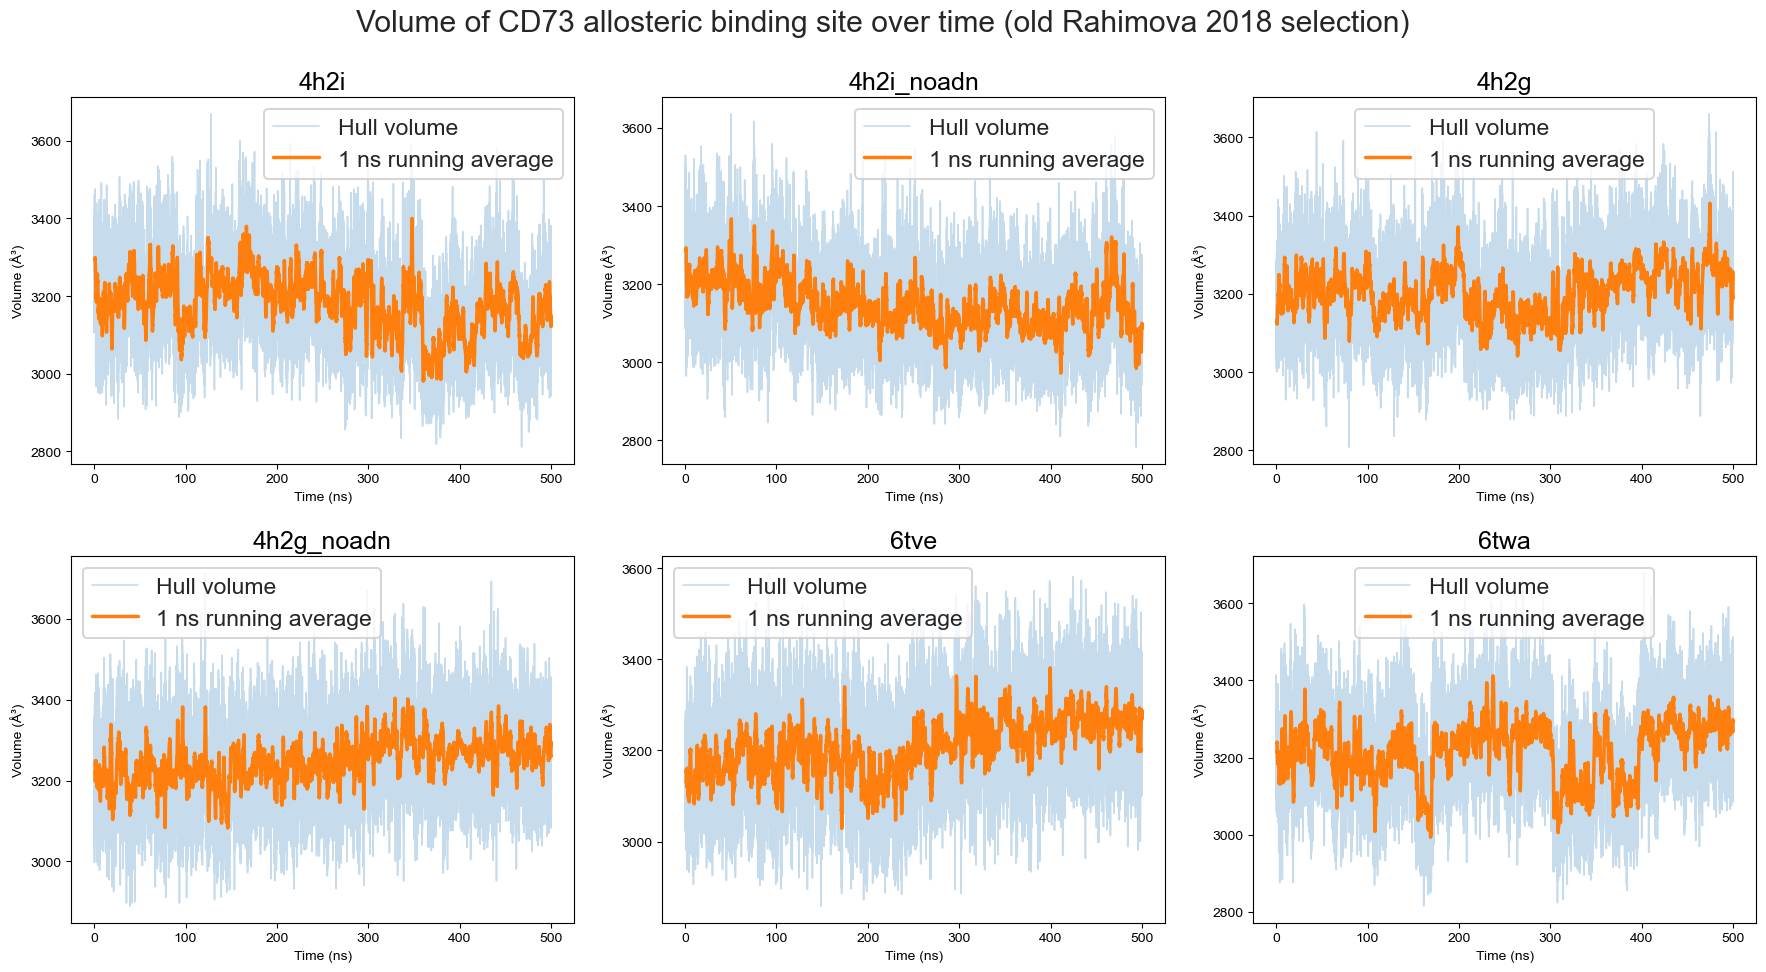

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for ax, (name, traj) in zip(axes, allosteric_bindingsite_trajectories_oldselection.items()):
    traj.plot_volume_over_time(
        title=f"{name}",
        ax=ax
    )

fig.suptitle("Volume of CD73 allosteric binding site over time (old Rahimova 2018 selection)")

plt.tight_layout()
plt.show()

100%|██████████| 50005/50005 [01:20<00:00, 618.48it/s]


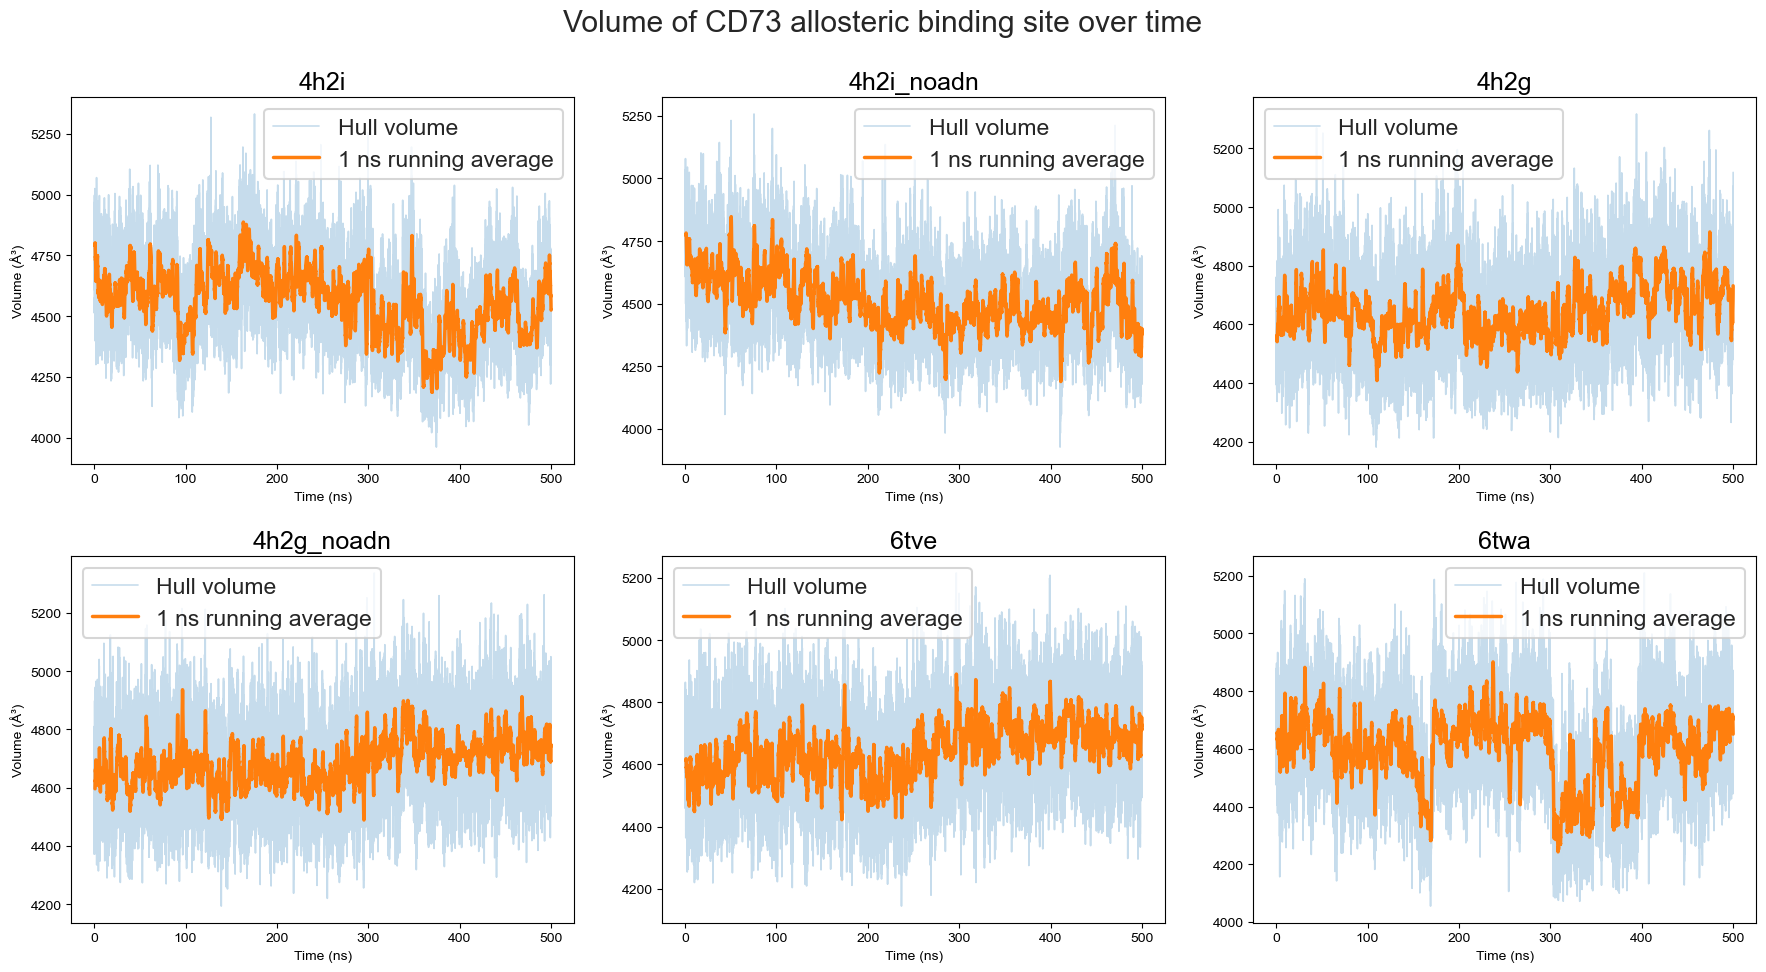

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for ax, (name, traj) in zip(axes, allosteric_bindingsite_trajectories.items()):
    traj.plot_volume_over_time(
        title=f"{name}",
        ax=ax
    )

fig.suptitle("Volume of CD73 allosteric binding site over time")

plt.tight_layout()
plt.show()

100%|██████████| 50005/50005 [01:28<00:00, 565.95it/s]


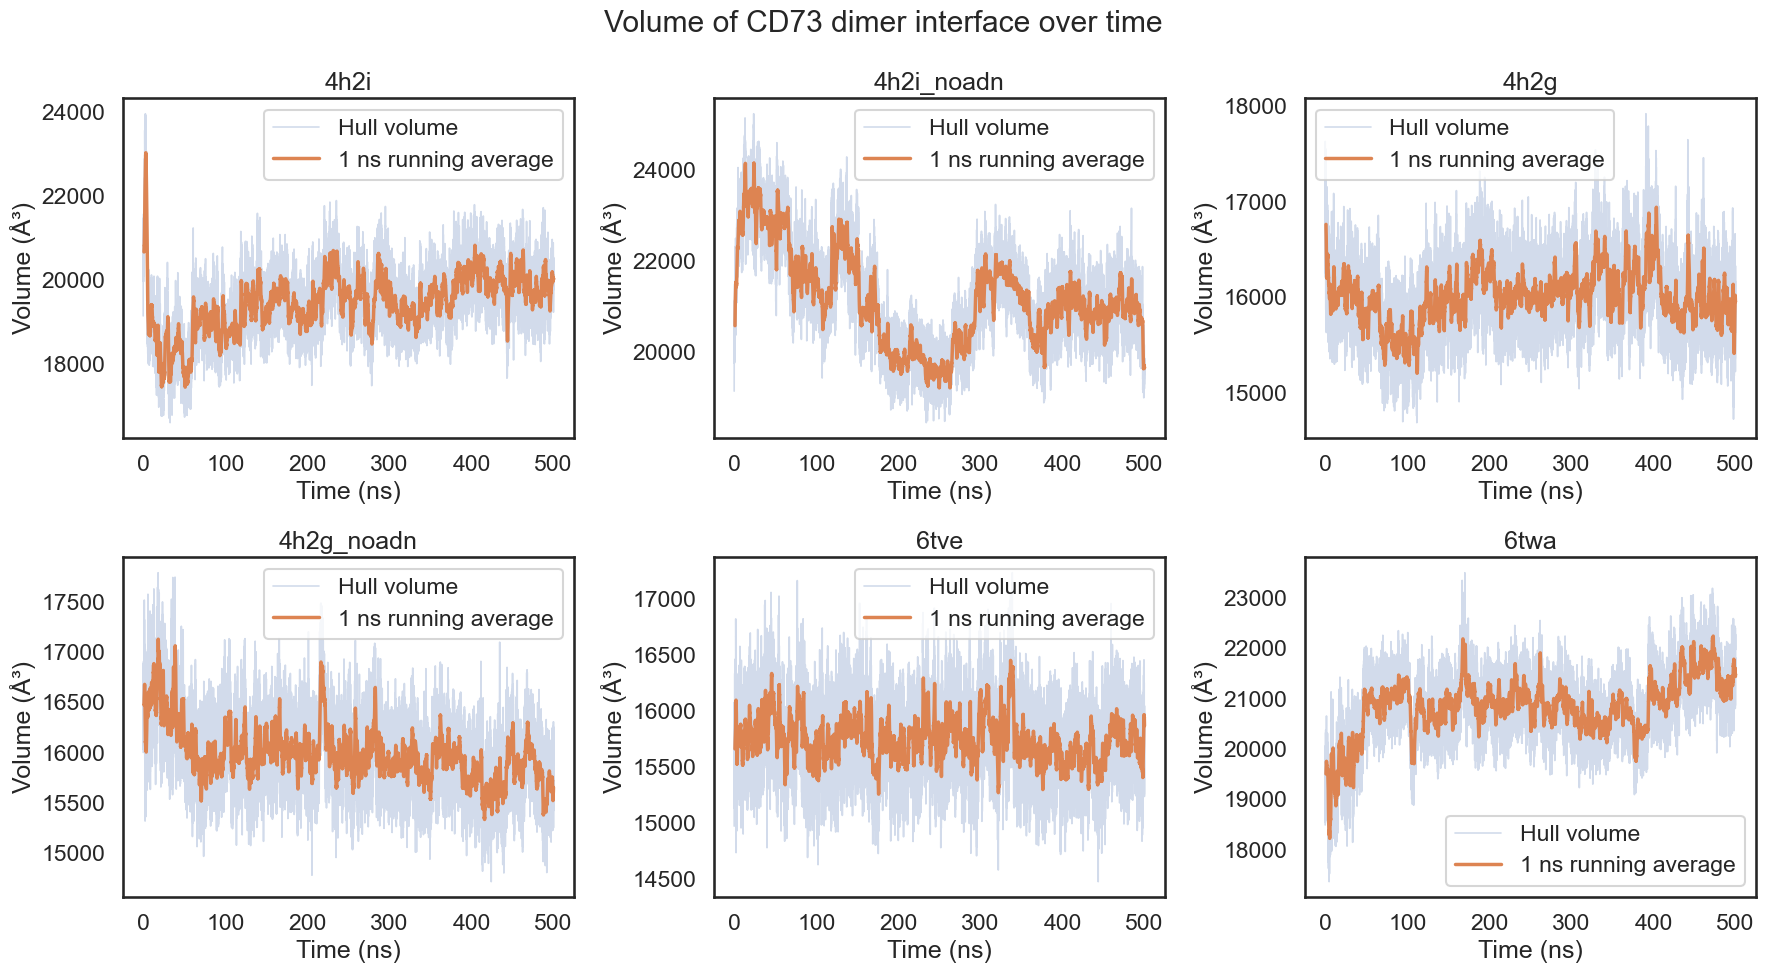

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for ax, (name, traj) in zip(axes, interface_trajectories.items()):
    traj.plot_volume_over_time(
        title=f"{name}",
        ax=ax
    )

fig.suptitle("Volume of CD73 dimer interface over time")

plt.tight_layout()
plt.show()

## Difference in dimer interface volume between open and closed structures
It can be observed that the closed (`6TWA`, `4H2I`) structures seem to have a larger dimer interface volume than the open-conformation protein (`6TVE`, `4H2G`). The binding pockets seem to differ by a lesser amount.

## RMSD of allosteric binding site residues

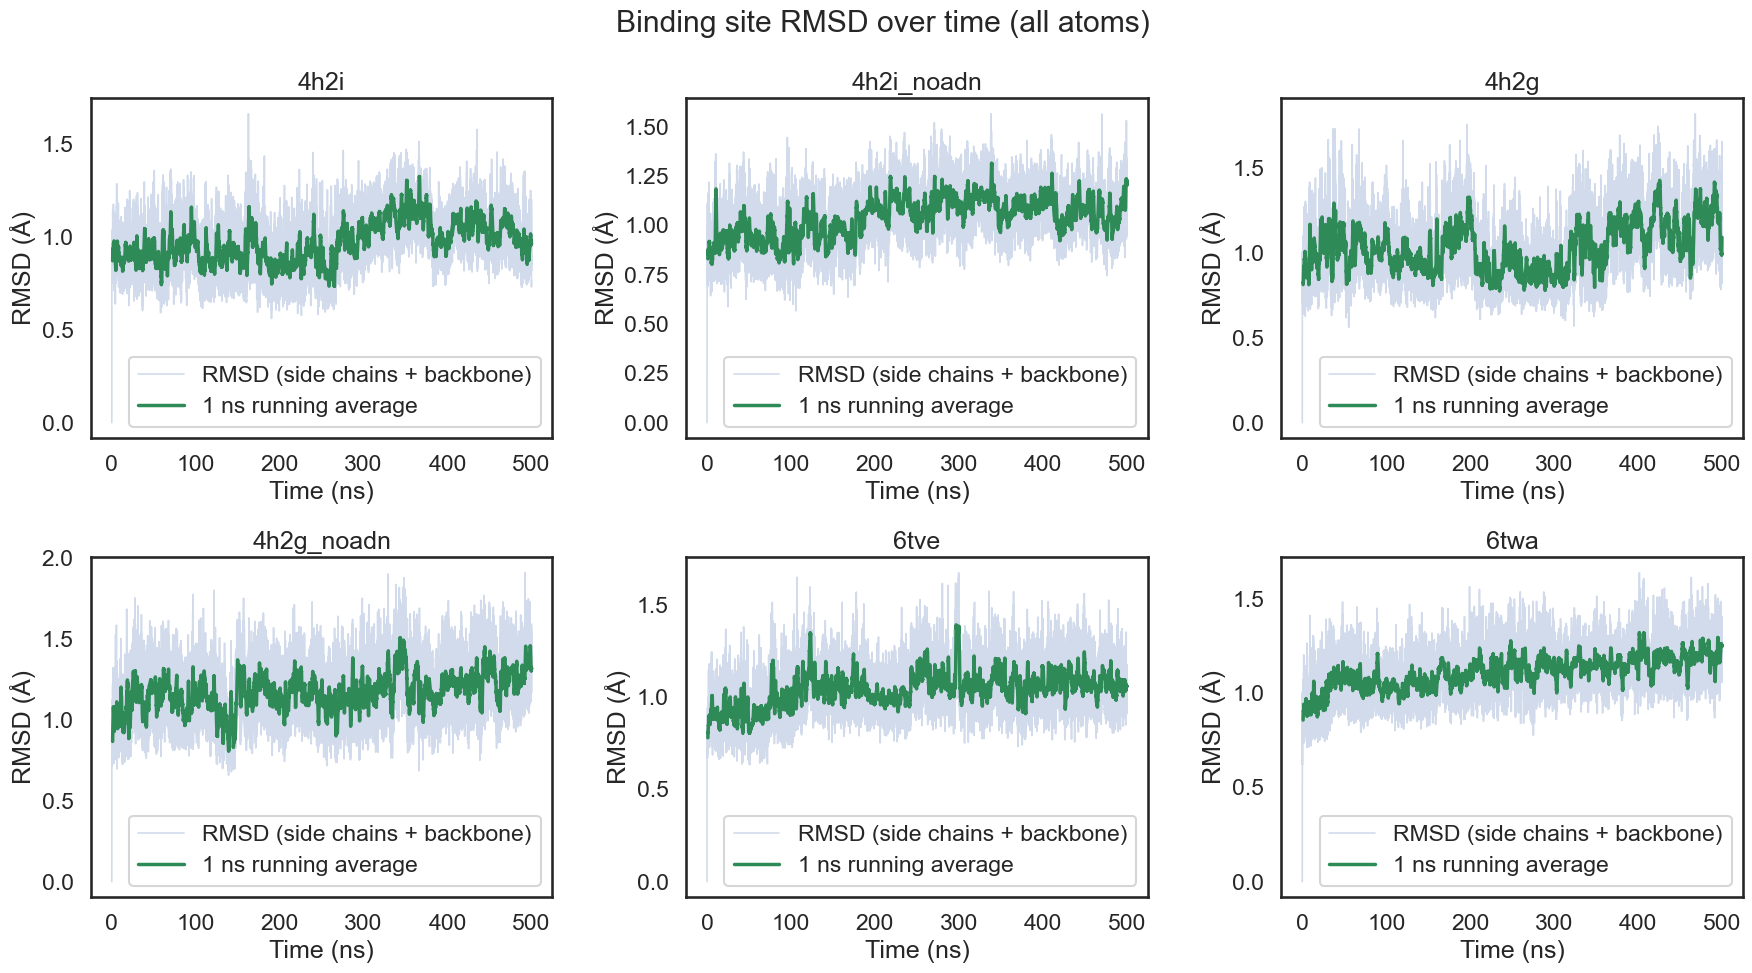

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for ax, (name, traj) in zip(axes, allosteric_bindingsite_trajectories.items()):
    traj.plot_rmsd_over_time(
        title=f"{name}",
        only_sidechains=False,
        ax=ax
    )

fig.suptitle("Binding site RMSD over time (all atoms)")

plt.tight_layout()
plt.show()

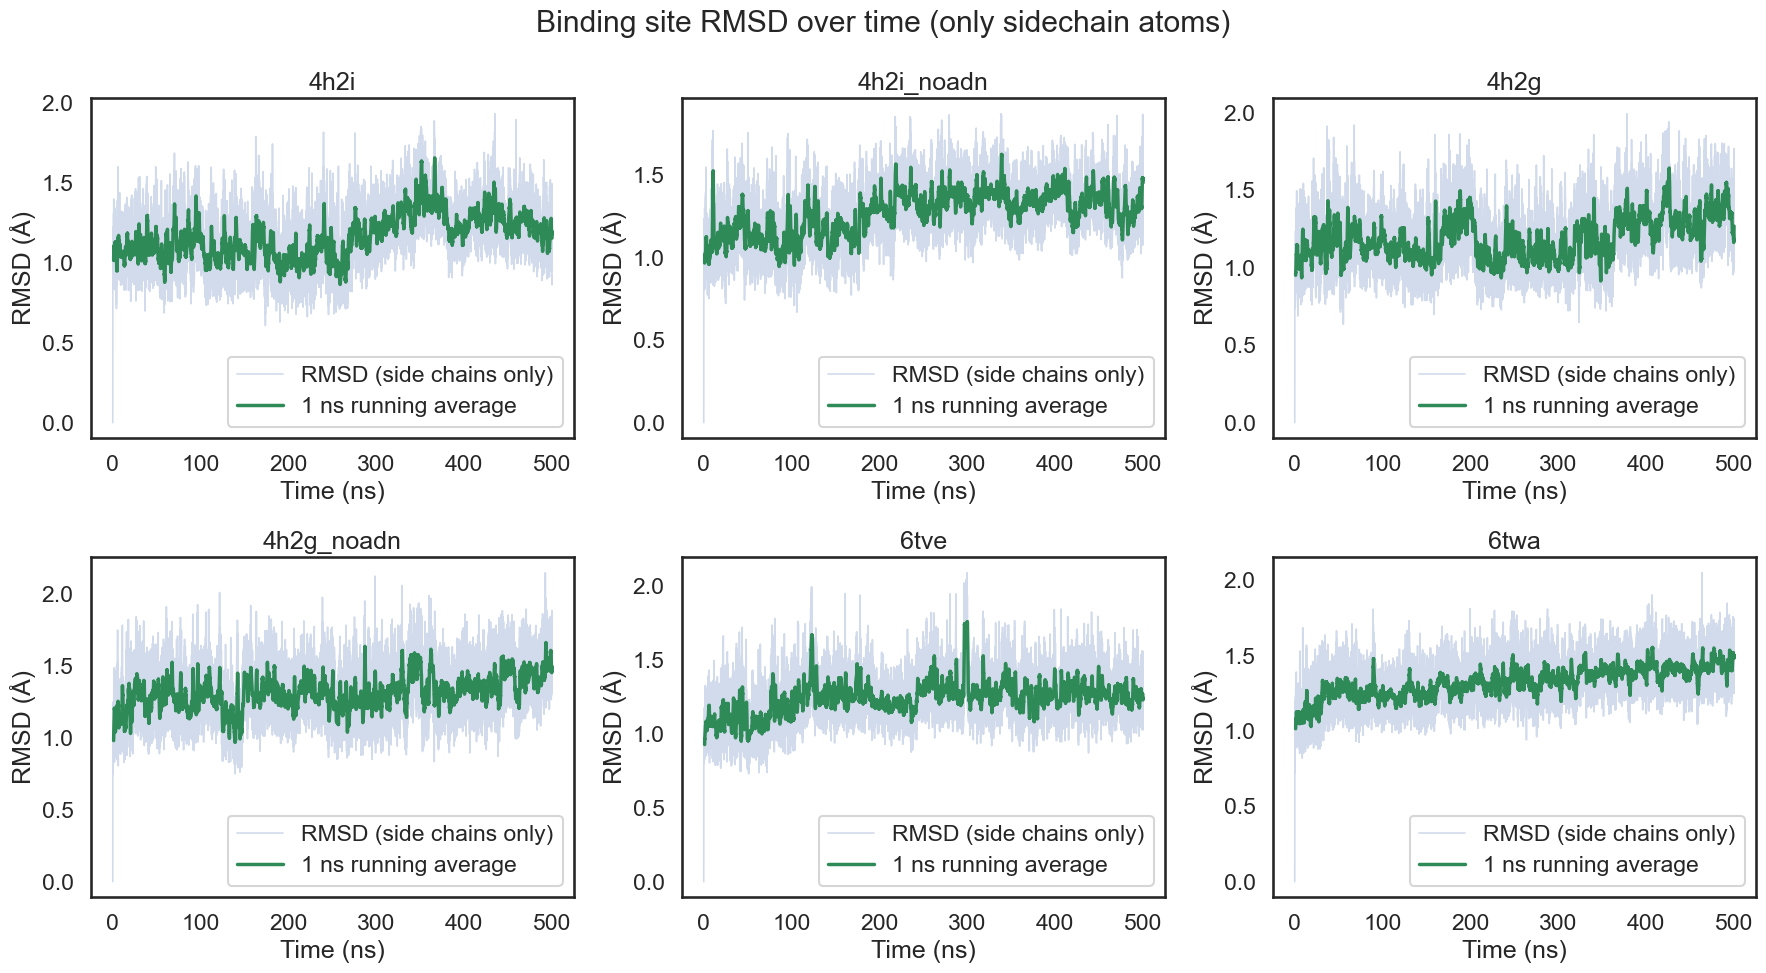

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for ax, (name, traj) in zip(axes, allosteric_bindingsite_trajectories.items()):
    traj.plot_rmsd_over_time(
        title=f"{name}",
        only_sidechains=True,
        ax=ax
    )

fig.suptitle("Binding site RMSD over time (only sidechain atoms)")

plt.tight_layout()
plt.show()

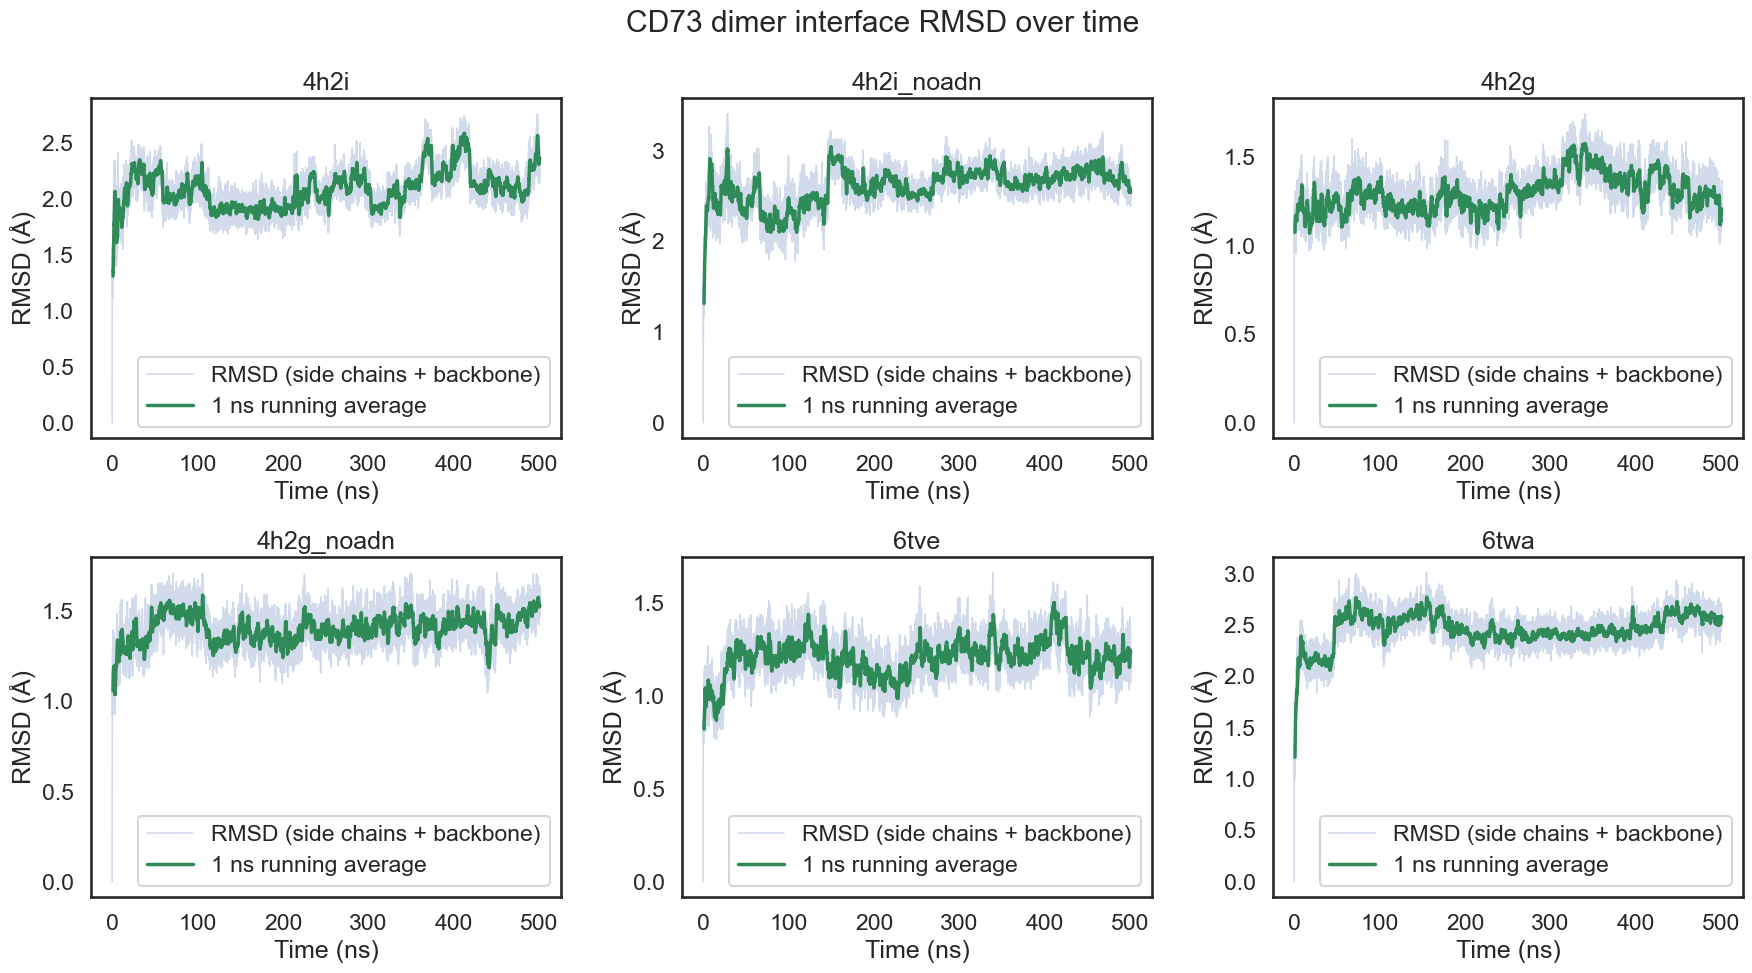

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for ax, (name, traj) in zip(axes, interface_trajectories.items()):
    traj.plot_rmsd_over_time(
        title=f"{name}",
        only_sidechains=False,
        ax=ax
    )

fig.suptitle("CD73 dimer interface RMSD over time")

plt.tight_layout()
plt.show()

In [11]:
allosteric_bindingsite_trajectories['4h2g'].write_system_frame_pdb(frame_index=5000)

Wrote system frame 5000 to PDB: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/frame_5000.pdb
Wrote hull PDB to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/hull_frame_5000.pdb
Wrote PyMol view script to /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/view_system_frame5000.pml


/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1336: UserWarning: Found missing chainIDs. Corresponding atoms will use value of 'X'
  warnings.warn(


# Autocorrelation time of allosteric binding site volumes and RMSD's 
Grossfield et al. (2019, https://livecomsjournal.org/index.php/livecoms/article/view/v1i1e5067/913) discusses the implementation of autocorrelation time analysis to estimate the number of independent samples in a (time series) MD trajectory. 

Here, I implement this analysis to calculate the autocorrelation time to 1. estimate standard uncertainty of the allosteric binding pocket volumes, and 2. find out the number of samples with statistically independent volumes for docking (check that my MD simulation time is long enough to sample independent conformers)

### Hull Volumes


In [10]:
rows = []

for name, traj in allosteric_bindingsite_trajectories.items():
    volumes = np.array([hull.volume for hull in traj.hulls])

    # Chodera / statistical inefficiency
    statistical_inefficiency_g = statistical_inefficiency_reworked(volumes, mintime=3)
    decorrelation_timescale_ps = statistical_inefficiency_g * traj.universe.trajectory.dt
    n_eff_from_g = effective_sample_size_from_g(len(volumes), statistical_inefficiency_g)
    
    # Integrated autocorrelation time
    tau_int = autocorrelation_time(volumes, traj.universe.trajectory.dt)
    n_eff_from_tau_int = effective_sample_size(volumes, traj.universe.trajectory.dt)

    # Mean, SEM, CIs
    mean = np.mean(volumes)
    sem = sem_from_chodera_reworked(volumes)
    ci_95_low, ci_95_high = ci_from_chodera_reworked(volumes)


    rows.append({
        "system": name,
        "statistical_inefficiency_g": statistical_inefficiency_g,
        "decorrelation_timescale_ps": decorrelation_timescale_ps,
        "n_eff_from_g": n_eff_from_g,
        "integrated_autocorrelation_time_ps": tau_int,
        "n_eff_from_tau_int": n_eff_from_tau_int,
        "mean_volume_a3": mean,
        "sem": sem,
        "ci_95_low": ci_95_low,
        "ci_95_high": ci_95_high
    })

bindingpocket_volume_statistics_df = pd.DataFrame(rows)
bindingpocket_volume_statistics_df

,system,statistical_inefficiency_g,decorrelation_timescale_ps,n_eff_from_g,integrated_autocorrelation_time_ps,n_eff_from_tau_int,mean_volume_a3,sem,ci_95_low,ci_95_high
0,4h2i,3281.538543,32815.385429,15.238279,18982.553355,13.171305,4563.293746,42.503959,4472.274740,4654.312752
1,4h2i_noadn,2542.522257,25425.222569,19.667871,15304.013418,16.337544,4511.470859,33.403761,4441.471698,4581.470020
2,4h2g,1097.227797,10972.277967,45.573946,5771.059331,43.323935,4648.166609,19.873454,4608.128855,4688.204362
3,4h2g_noadn,1203.913760,12039.137599,41.534536,6427.191320,38.900351,4687.377027,20.184583,4646.599215,4728.154840
4,6tve,1931.814343,19318.143431,25.885510,11021.858223,22.684923,4643.966100,26.093204,4590.213602,4697.718598
5,6twa,1519.978368,15199.783681,32.898495,7887.031144,31.700775,4594.321088,27.684971,4537.921609,4650.720568


In [11]:
rows = []

for name, traj in interface_trajectories.items():
    volumes = np.array([hull.volume for hull in traj.hulls])

    # Chodera / statistical inefficiency
    statistical_inefficiency_g = statistical_inefficiency_reworked(volumes, mintime=3)
    decorrelation_timescale_ps = statistical_inefficiency_g * traj.universe.trajectory.dt
    n_eff_from_g = effective_sample_size_from_g(len(volumes), statistical_inefficiency_g)
    
    # Integrated autocorrelation time
    tau_int = autocorrelation_time(volumes, traj.universe.trajectory.dt)
    n_eff_from_tau_int = effective_sample_size(volumes, traj.universe.trajectory.dt)

    # Mean, SEM, CIs
    mean = np.mean(volumes)
    sem = sem_from_chodera_reworked(volumes)
    ci_95_low, ci_95_high = ci_from_chodera_reworked(volumes)


    rows.append({
        "system": name,
        "statistical_inefficiency_g": statistical_inefficiency_g,
        "decorrelation_timescale_ps": decorrelation_timescale_ps,
        "n_eff_from_g": n_eff_from_g,
        "integrated_autocorrelation_time_ps": tau_int,
        "n_eff_from_tau_int": n_eff_from_tau_int,
        "mean_volume_a3": mean,
        "sem": sem,
        "ci_95_low": ci_95_low,
        "ci_95_high": ci_95_high
    })

interface_volume_statistics_df = pd.DataFrame(rows)
interface_volume_statistics_df

,system,statistical_inefficiency_g,decorrelation_timescale_ps,n_eff_from_g,integrated_autocorrelation_time_ps,n_eff_from_tau_int,mean_volume_a3,sem,ci_95_low,ci_95_high
0,4h2i,3602.535038,36025.350379,13.880503,19307.262236,12.949790,19442.998282,210.256230,18988.338571,19897.657993
1,4h2i_noadn,6442.246046,64422.460455,7.762200,34293.869734,7.290807,21152.160459,391.897214,20218.823506,22085.497413
2,4h2g,1917.650661,19176.506605,26.076178,10060.419152,24.852344,16004.390214,70.364524,15859.494083,16149.286345
3,4h2g_noadn,2067.574822,20675.748216,24.184856,11888.947813,21.029615,15987.719192,72.764256,15837.261241,16138.177144
4,6tve,295.748120,2957.481201,169.083070,1492.191633,167.558908,15743.452284,23.366220,15697.323204,15789.581365
5,6twa,2610.559813,26105.598127,19.154895,13485.647335,18.540081,20834.285412,150.377355,20518.547413,21150.023410


### RMSD

In [12]:
rows = []

for name, traj in allosteric_bindingsite_trajectories.items():
    rmsd = traj.rmsd.rmsd[:,2]

    # Chodera / statistical inefficiency
    statistical_inefficiency_g = statistical_inefficiency_reworked(rmsd, mintime=3)
    decorrelation_timescale_ps = statistical_inefficiency_g * traj.universe.trajectory.dt
    n_eff_from_g = effective_sample_size_from_g(len(rmsd), statistical_inefficiency_g)
    
    # Integrated autocorrelation time
    tau_int = autocorrelation_time(rmsd, traj.universe.trajectory.dt)
    n_eff_from_tau_int = effective_sample_size(rmsd, traj.universe.trajectory.dt)

    # Mean, SEM, CIs
    mean = np.mean(rmsd)
    sem = sem_from_chodera_reworked(rmsd)
    ci_95_low, ci_95_high = ci_from_chodera_reworked(rmsd)


    rows.append({
        "system": name,
        "statistical_inefficiency_g": statistical_inefficiency_g,
        "decorrelation_timescale_ps": decorrelation_timescale_ps,
        "n_eff_from_g": n_eff_from_g,
        "integrated_autocorrelation_time_ps": tau_int,
        "n_eff_from_tau_int": n_eff_from_tau_int,
        "mean_rmsd_a": mean,
        "sem": sem,
        "ci_95_low": ci_95_low,
        "ci_95_high": ci_95_high
    })

bindingpocket_rmsd_statistics_df = pd.DataFrame(rows)
bindingpocket_rmsd_statistics_df

,system,statistical_inefficiency_g,decorrelation_timescale_ps,n_eff_from_g,integrated_autocorrelation_time_ps,n_eff_from_tau_int,mean_rmsd_a,sem,ci_95_low,ci_95_high
0,4h2i,4203.946706,42039.467055,11.894775,23727.469781,10.537365,0.971132,0.039921,0.883162,1.059102
1,4h2i_noadn,4779.523336,47795.233357,10.462550,29413.284129,8.500581,1.038717,0.039167,0.950770,1.126665
2,4h2g,2787.664122,27876.641221,17.937957,14952.975768,16.720752,1.032706,0.042095,0.943869,1.121543
3,4h2g_noadn,1108.941215,11089.412149,45.091660,5852.220709,42.722244,1.169881,0.024581,1.120346,1.219417
4,6tve,1878.079256,18780.792564,26.626139,9895.912471,25.265987,1.040438,0.024728,0.989572,1.091303
5,6twa,3750.015719,37500.157187,13.334611,26401.811968,9.469994,1.111511,0.031965,1.042074,1.180949


In [13]:
rows = []

for name, traj in interface_trajectories.items():
    rmsd = traj.rmsd.rmsd[:,2]

    # Chodera / statistical inefficiency
    statistical_inefficiency_g = statistical_inefficiency_reworked(rmsd, mintime=3)
    decorrelation_timescale_ps = statistical_inefficiency_g * traj.universe.trajectory.dt
    n_eff_from_g = effective_sample_size_from_g(len(rmsd), statistical_inefficiency_g)
    
    # Integrated autocorrelation time
    tau_int = autocorrelation_time(rmsd, traj.universe.trajectory.dt)
    n_eff_from_tau_int = effective_sample_size(rmsd, traj.universe.trajectory.dt)

    # Mean, SEM, CIs
    mean = np.mean(rmsd)
    sem = sem_from_chodera_reworked(rmsd)
    ci_95_low, ci_95_high = ci_from_chodera_reworked(rmsd)


    rows.append({
        "system": name,
        "statistical_inefficiency_g": statistical_inefficiency_g,
        "decorrelation_timescale_ps": decorrelation_timescale_ps,
        "n_eff_from_g": n_eff_from_g,
        "integrated_autocorrelation_time_ps": tau_int,
        "n_eff_from_tau_int": n_eff_from_tau_int,
        "mean_rmsd_a": mean,
        "sem": sem,
        "ci_95_low": ci_95_low,
        "ci_95_high": ci_95_high
    })

interface_rmsd_statistics_df = pd.DataFrame(rows)
interface_rmsd_statistics_df

,system,statistical_inefficiency_g,decorrelation_timescale_ps,n_eff_from_g,integrated_autocorrelation_time_ps,n_eff_from_tau_int,mean_rmsd_a,sem,ci_95_low,ci_95_high
0,4h2i,3570.603147,35706.031471,14.004637,18844.970207,13.267466,2.084226,0.047809,1.980946,2.187507
1,4h2i_noadn,4406.125487,44061.254869,11.349200,31684.449107,7.891253,2.608884,0.063846,2.467276,2.750493
2,4h2g,5642.049021,56420.490214,8.862915,31380.354894,7.967564,1.298178,0.037959,1.210379,1.385977
3,4h2g_noadn,1313.645183,13136.451830,38.065073,6719.064882,37.210535,1.406108,0.015154,1.375406,1.436811
4,6tve,1932.440653,19324.406534,25.877121,9920.864746,25.202440,1.206830,0.021658,1.162213,1.251447
5,6twa,2968.963474,29689.634741,16.842578,15308.854640,16.332051,2.459258,0.040884,2.372517,2.545999


In [6]:
# bindingpocket_volume_statistics_df.to_csv("./data/bindingpocket_volume_statistics.csv", index=False)
# bindingpocket_rmsd_statistics_df.to_csv("./data/bindingpocket_rmsd_statistics.csv", index=False)
# interface_volume_statistics_df.to_csv("./data/interface_volume_statistics.csv", index=False)
# interface_rmsd_statistics_df.to_csv("./data/interface_rmsd_statistics.csv", index=False)

bindingpocket_volume_statistics_df = pd.read_csv("./data/bindingpocket_volume_statistics.csv")
bindingpocket_rmsd_statistics_df = pd.read_csv("./data/bindingpocket_rmsd_statistics.csv")
interface_volume_statistics_df = pd.read_csv("./data/interface_volume_statistics.csv")
interface_rmsd_statistics_df = pd.read_csv("./data/interface_rmsd_statistics.csv")

### Calculating stat. sign. differences

In [67]:
allosteric_bindingsite_trajectories['4h2g'].rmsd.rmsd[:,2]

array([0.        , 0.7926102 , 0.74577461, ..., 1.45433547, 1.4035312 ,
       1.51724331], shape=(50005,))

In [94]:
def find_significant_differences_by_blocks(trajectories: dict[str, Trajectory], pairs: list[tuple], block_length_ns: float, variable: str) -> None:

    def block_means(timeseries: np.ndarray, block_size: int) -> np.ndarray:
        timeseries = np.array(timeseries)
        n_blocks = len(timeseries) // block_size
        trimmed = timeseries[:n_blocks * block_size]
        reshaped = trimmed.reshape(n_blocks, block_size)
        return n_blocks, reshaped.mean(axis=1)
    
    print(f"Printing stat. sign. differences for {variable} for systems using block averaging")

    for pair in pairs:
        system_a = pair[0]
        system_b = pair[1]

        if variable == "volume":
            timeseries_a = [hull.volume for hull in trajectories[system_a].hulls]
            timeseries_b = [hull.volume for hull in trajectories[system_b].hulls]
        elif variable == "rmsd":
            timeseries_a = trajectories[system_a].rmsd.rmsd[:,2]
            timeseries_b = trajectories[system_b].rmsd.rmsd[:,2]
        else:
            raise ValueError(f"variable {variable} not valid")

        block_size_a = int(block_length_ns * 1000 / trajectories[system_a].universe.trajectory.dt)
        block_size_b = int(block_length_ns * 1000 / trajectories[system_b].universe.trajectory.dt)

        n_blocks_a, means_a = block_means(timeseries_a, block_size_a)
        n_blocks_b, means_b = block_means(timeseries_b, block_size_b)

        result = ttest_ind(
            means_a,
            means_b,
            equal_var=False
        )
        
        print(f"{system_a} (block mean {np.mean(means_a)} for {n_blocks_a} blocks) and {system_b} (block mean {np.mean(means_b)} for {n_blocks_b} blocks)\t p-val: {result.pvalue}", end="")
        if result.pvalue < 0.05:
            print(" ***")
        else:
            print("")



In [ ]:
def find_significant_differences_by_sem(pairs: list[tuple], dataframe: pd.DataFrame, variable: str) -> None:
    print(f"Stat. significant differences for {variable} for systems by SEM:")

    for pair in pairs:

        system_a = pair[0]
        system_b = pair[1]

        mean_a = dataframe[dataframe['system'] == system_a][variable].item()
        mean_b = dataframe[dataframe['system'] == system_b][variable].item()

        sem_a = dataframe[dataframe['system'] == system_a]['sem'].item()
        sem_b = dataframe[dataframe['system'] == system_b]['sem'].item()

        z = (mean_a - mean_b) / np.sqrt((sem_a ** 2) + (sem_b ** 2))
        p = 2 * (1 - norm.cdf(abs(z)))
        
        print(f"Difference between {pair[0]} ({round(mean_a, 2)}) and {pair[1]} ({round(mean_b, 2)}): p-val {round(p, 4)}", end="")
        if p < 0.05:
            print(" ***")
        else:
            print("")

In [114]:
pairs = list(combinations(list(bindingpocket_volume_statistics_df['system']), 2))

print("Volume of allosteric binding pockets:")
find_significant_differences_by_blocks(trajectories = allosteric_bindingsite_trajectories,
                                       pairs=pairs,
                                       block_length_ns=60, # block length 60ns larger than largest integrated autocorrelation time of 18.9ns for binding pocket volumes
                                       variable="volume")
print("\n")
print("Volume of dimer interface")
find_significant_differences_by_blocks(trajectories = interface_trajectories,
                                       pairs=pairs,
                                       block_length_ns=100, # block length 100ns larger than largest integrated autocorrelation time of 38ns for interface volumes
                                       variable="volume")

Volume of allosteric binding pockets:
Printing stat. sign. differences for volume for systems using block averaging
4h2i (block mean 4563.051219632404 for 8 blocks) and 4h2i_noadn (block mean 4515.783433289122 for 8 blocks)	 p-val: 0.2778176433690499
4h2i (block mean 4563.051219632404 for 8 blocks) and 4h2g (block mean 4646.031312705965 for 8 blocks)	 p-val: 0.052074452544466826
4h2i (block mean 4563.051219632404 for 8 blocks) and 4h2g_noadn (block mean 4685.2029905609925 for 8 blocks)	 p-val: 0.008797319340275389 ***
4h2i (block mean 4563.051219632404 for 8 blocks) and 6tve (block mean 4642.322163570527 for 8 blocks)	 p-val: 0.06758990565076722
4h2i (block mean 4563.051219632404 for 8 blocks) and 6twa (block mean 4590.927355770527 for 8 blocks)	 p-val: 0.5473601493955998
4h2i_noadn (block mean 4515.783433289122 for 8 blocks) and 4h2g (block mean 4646.031312705965 for 8 blocks)	 p-val: 0.000688417187844761 ***
4h2i_noadn (block mean 4515.783433289122 for 8 blocks) and 4h2g_noadn (block

In [108]:
# Calculate stat. sign. differences
pairs = list(combinations(list(bindingpocket_volume_statistics_df['system']), 2))

print("Volume of allosteric binding pockets:")
find_significant_differences_by_sem(pairs = pairs, dataframe = bindingpocket_volume_statistics_df, variable = 'mean_volume_a3')
print("\n")
print("Volume of dimer interface")
find_significant_differences_by_sem(pairs = pairs, dataframe = interface_volume_statistics_df, variable = 'mean_volume_a3')

Volume of allosteric binding pockets:
Stat. significant differences for mean_volume_a3 for systems by SEM:
Difference between 4h2i (4563.29) and 4h2i_noadn (4511.47): p-val 0.3377
Difference between 4h2i (4563.29) and 4h2g (4648.17): p-val 0.0705
Difference between 4h2i (4563.29) and 4h2g_noadn (4687.38): p-val 0.0084 ***
Difference between 4h2i (4563.29) and 6tve (4643.97): p-val 0.1058
Difference between 4h2i (4563.29) and 6twa (4594.32): p-val 0.5408
Difference between 4h2i_noadn (4511.47) and 4h2g (4648.17): p-val 0.0004 ***
Difference between 4h2i_noadn (4511.47) and 4h2g_noadn (4687.38): p-val 0.0 ***
Difference between 4h2i_noadn (4511.47) and 6tve (4643.97): p-val 0.0018 ***
Difference between 4h2i_noadn (4511.47) and 6twa (4594.32): p-val 0.0562
Difference between 4h2g (4648.17) and 4h2g_noadn (4687.38): p-val 0.1663
Difference between 4h2g (4648.17) and 6tve (4643.97): p-val 0.8981
Difference between 4h2g (4648.17) and 6twa (4594.32): p-val 0.1141
Difference between 4h2g_noad

## Investigation of highly flexible residues

Starting 4h2i
RMSF done in 64.6s


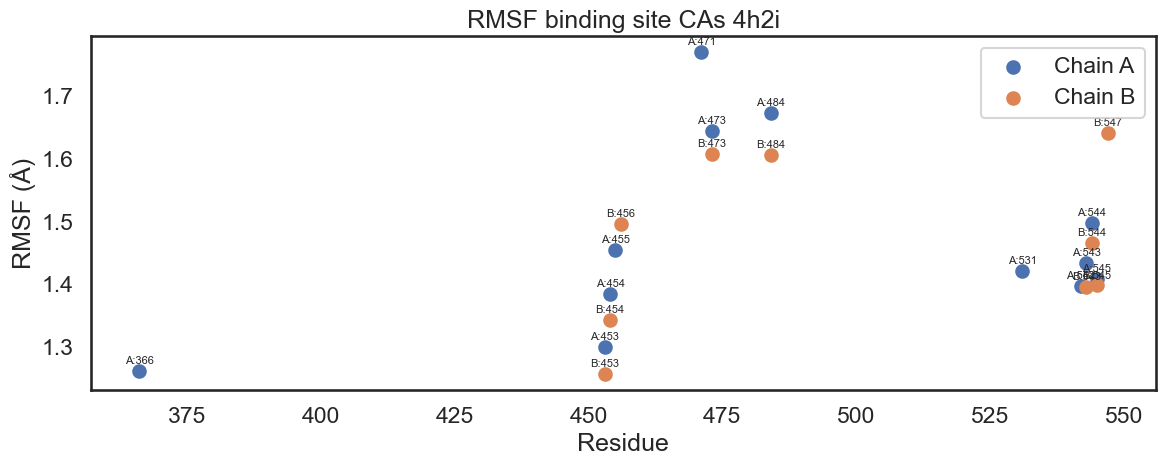

Finished 4h2i
Starting 4h2i_noadn
RMSF done in 61.8s


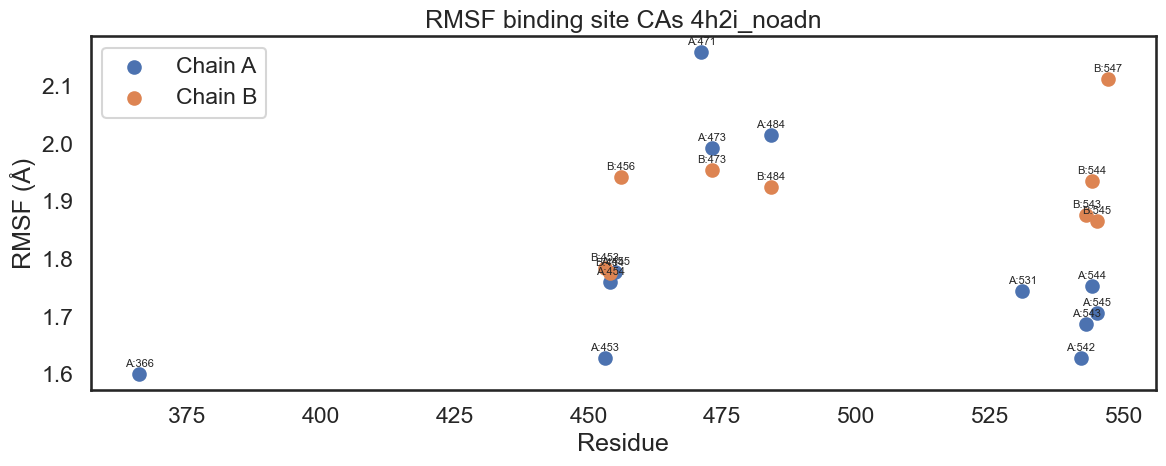

Finished 4h2i_noadn
Starting 4h2g
RMSF done in 60.7s


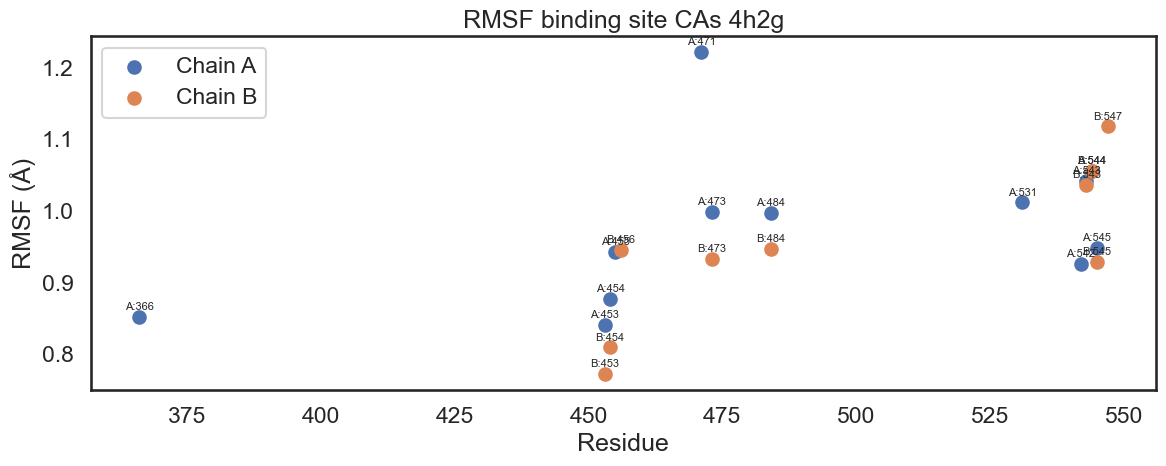

Finished 4h2g
Starting 4h2g_noadn
RMSF done in 62.8s


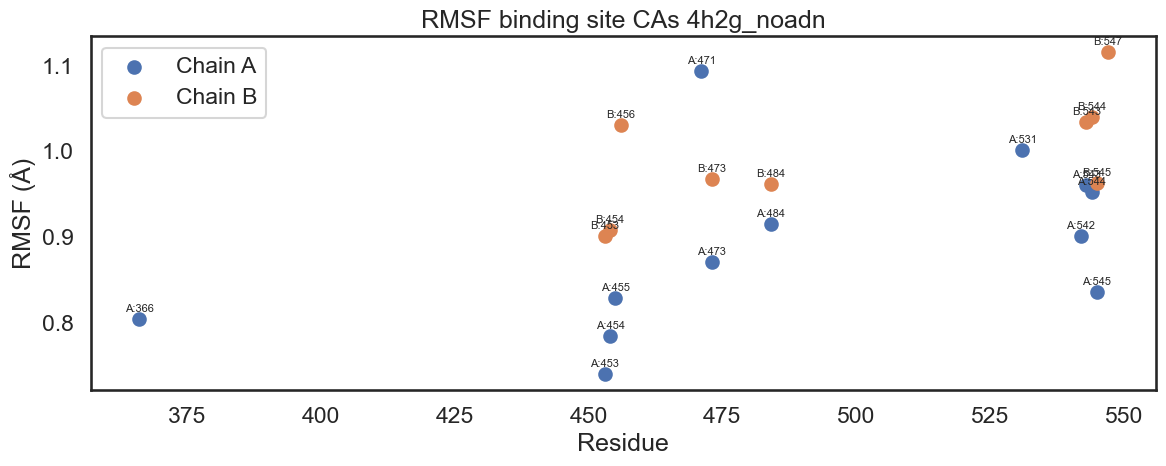

Finished 4h2g_noadn
Starting 6tve
RMSF done in 62.2s


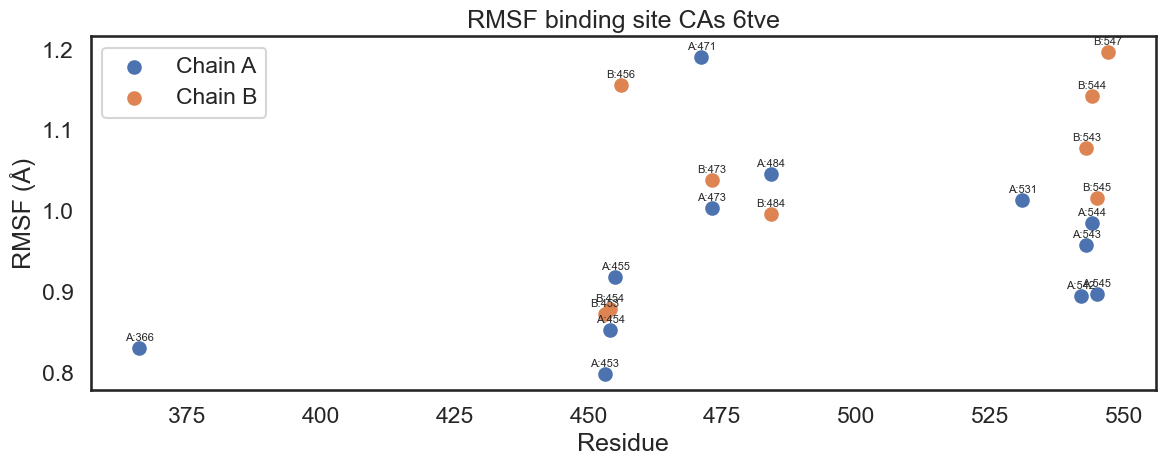

Finished 6tve
Starting 6twa
RMSF done in 23.8s


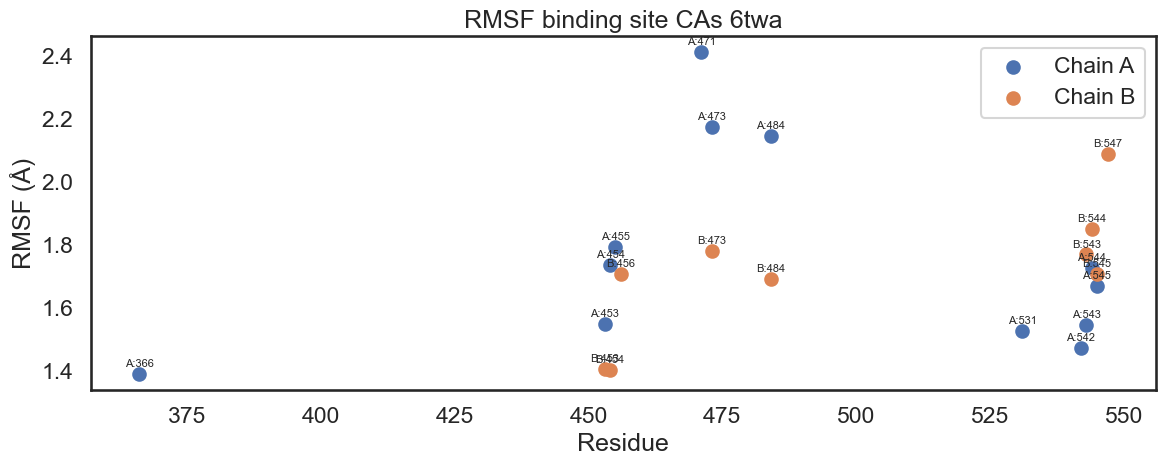

Finished 6twa


In [15]:
import time

rmsf_dfs = {}

for name, traj in allosteric_bindingsite_trajectories.items():

    t0 = time.time()
    print(f"Starting {name}")

    sel = traj.residue_atoms.select_atoms('protein and name CA')

    bindingsite_RMSF = rms.RMSF(sel)
    bindingsite_RMSF.run()

    print(f"RMSF done in {time.time() - t0:.1f}s")

    rmsf_df = pd.DataFrame({
        "chain": sel.segids,
        "resid": sel.resids,
        "rmsf": bindingsite_RMSF.results.rmsf
    })

    rmsf_dfs[name] = rmsf_df

    fig, ax = plt.subplots(figsize=(12, 5))

    for chain, subdf in rmsf_df.groupby("chain"):

        # scatter only, no connecting lines
        ax.scatter(
            subdf["resid"],
            subdf["rmsf"],
            label=f"Chain {chain}"
        )

        # annotate every point
        for _, row in subdf.iterrows():
            ax.annotate(
                f"{row['chain']}:{row['resid']}",
                (row["resid"], row["rmsf"]),
                textcoords="offset points",
                xytext=(0, 5),
                ha='center',
                fontsize=8
            )

    ax.set_xlabel("Residue")
    ax.set_ylabel("RMSF (Å)")
    ax.set_title(f"RMSF binding site CAs {name}")
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    print(f"Finished {name}")

Key flexible residues are several lysines (K471-A, K547-B), tyrosines (Y484-A+B, Y531-A), aspartate 473-A, histidine H456-B, and glycine G544-B.

The Glu 543-A,B seem to have moderately low RMSF values. This puts more confidence in centering the docking box around this residue, which was done by the Montpellier-group. Still, other flexible residues can lead to great variability between ensemble docking structures. 

## Dihedral analysis / clustering

Here follows a analysis of the dihedral angles of the flexible residues above (excluding glycine G544-B) to identify if there are possible rotamers that are visited regularly and should be included in the ensemble docking structures.

- $\chi_1$ angle: N-CA-CB-CG (rotation of CA-CB bond)
- $\chi_2$ angle: CA-CB-CG-CD (rotation of CB-CG bond)

In [148]:
dihedral_inspection_sel = [
    (471, "A"), (547, "B"),
    (484, "A"), (484, "B"), (531, "A"), 
    (473, "A"), (456, "B"),
]

BINDING_SITE_RESIDUES_onlyJanins = [
    (366, "A"), (456, "B"), (543, "A"), (543, "B"), (484, "A"), (484, "B"), (547, "B"),     # Major H-bond ints in top hits, Fig 6 Rahimova 2018 and text  
    (473, "A"), (473, "B"), (545, "A"), (545, "B"), (471, "A"),                             # Charged residues with non bonding ints, described in text
    (455, "A"),                                                                             # H-bond ints in Fig 6 with RR6, RR4
    (366, "A"), (531, "A"),                                                                 # D366 makes H-bond, Y531 Pi-stack (Grosjean 2025)    
]

In [155]:
janin_results = {}

for name, traj in allosteric_bindingsite_trajectories.items():
    print(f"doing trajectory {name}")
    janin_results[name] = {}

    for residue in BINDING_SITE_RESIDUES_onlyJanins:
        residue_key = f"{residue[0]}-{residue[1]}"
        janin_results[name][residue_key] = {}

        janin = Janin(
            traj.universe.select_atoms(f"protein and resid {residue[0]} and segid {residue[1]}")
        )
        print(f"started Janin for {residue}")
        janin.run()

        angles = janin.results.angles[:, 0, :]
        chi1 = list(angles[:, 0])
        chi2 = list(angles[:, 1])

        janin_results[name][residue_key]["chi1"] = chi1
        janin_results[name][residue_key]["chi2"] = chi2



doing trajectory 4h2i
started Janin for (366, 'A')
started Janin for (456, 'B')


KeyboardInterrupt: 

### Saving / Loading Janin dihedral angle-results

In [154]:
for key, subdict in janin_results.items():
    print(subdict.keys())

dict_keys(['471-A', '547-B', '484-A', '484-B', '531-A', '473-A', '456-B'])
dict_keys(['471-A', '547-B', '484-A', '484-B', '531-A', '473-A', '456-B'])
dict_keys(['471-A', '547-B', '484-A', '484-B', '531-A', '473-A', '456-B'])
dict_keys(['471-A', '547-B', '484-A', '484-B', '531-A', '473-A', '456-B'])
dict_keys(['471-A', '547-B', '484-A', '484-B', '531-A', '473-A', '456-B'])
dict_keys(['471-A', '547-B', '484-A', '484-B', '531-A', '473-A', '456-B'])


In [ ]:
# Saving / Loading Janin results as .JSON

#with open("./data/janin_results.json", "w") as f:
#   json.dump(janin_results, f)

# with open("./data/janin_results.json", "w") as f:
#     json.dump(
#         {k: vars(v) for k, v in janin_results.items()},
#         f,
#         indent=2
#     )

# janin_results = json.load(open("./data/janin_results.json"))

# # ----------------


# for key, subdict in janin_results.items():
#     with open(f"./data/janin_{key}_results.json", "w") as f:
#         json.dump(subdict, f, indent=2)


## Dihedral angle distributions of key residues

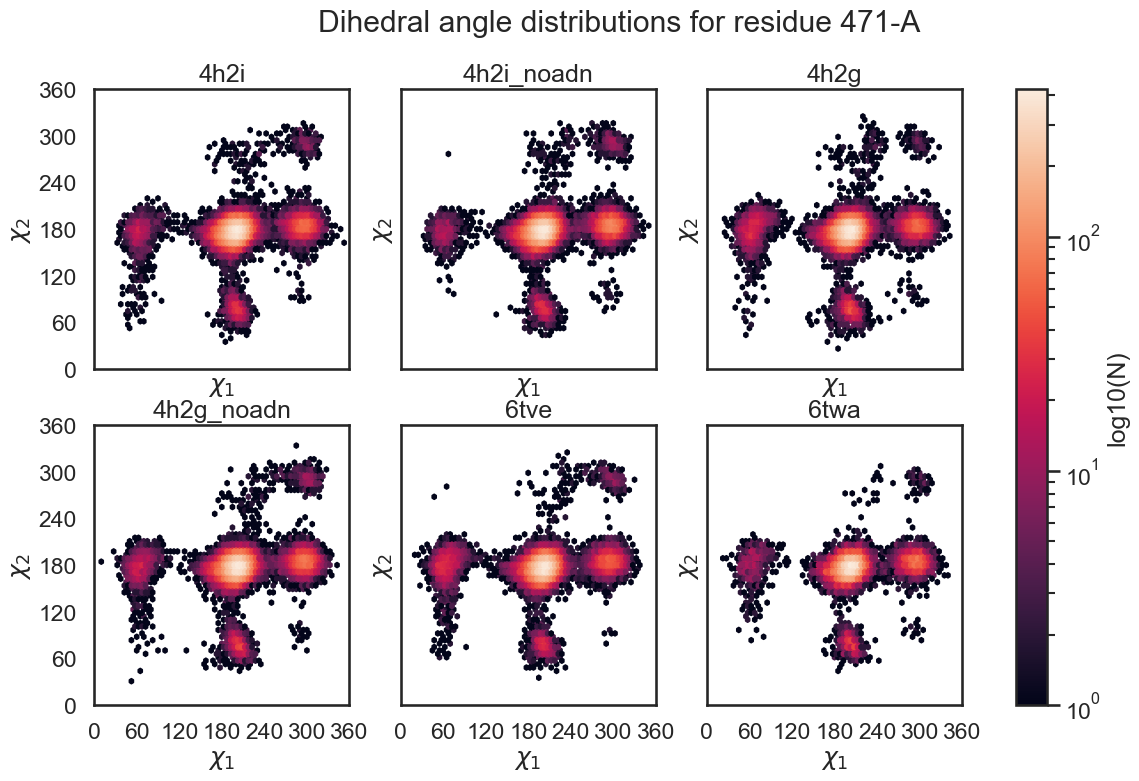

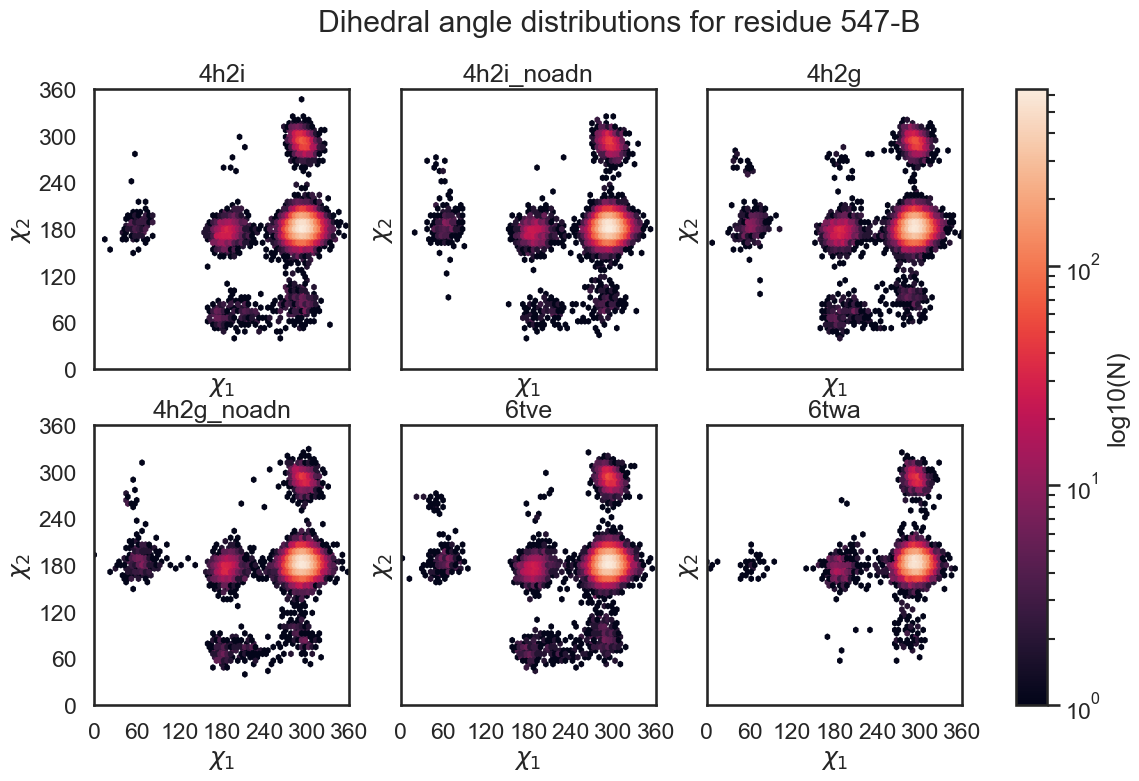

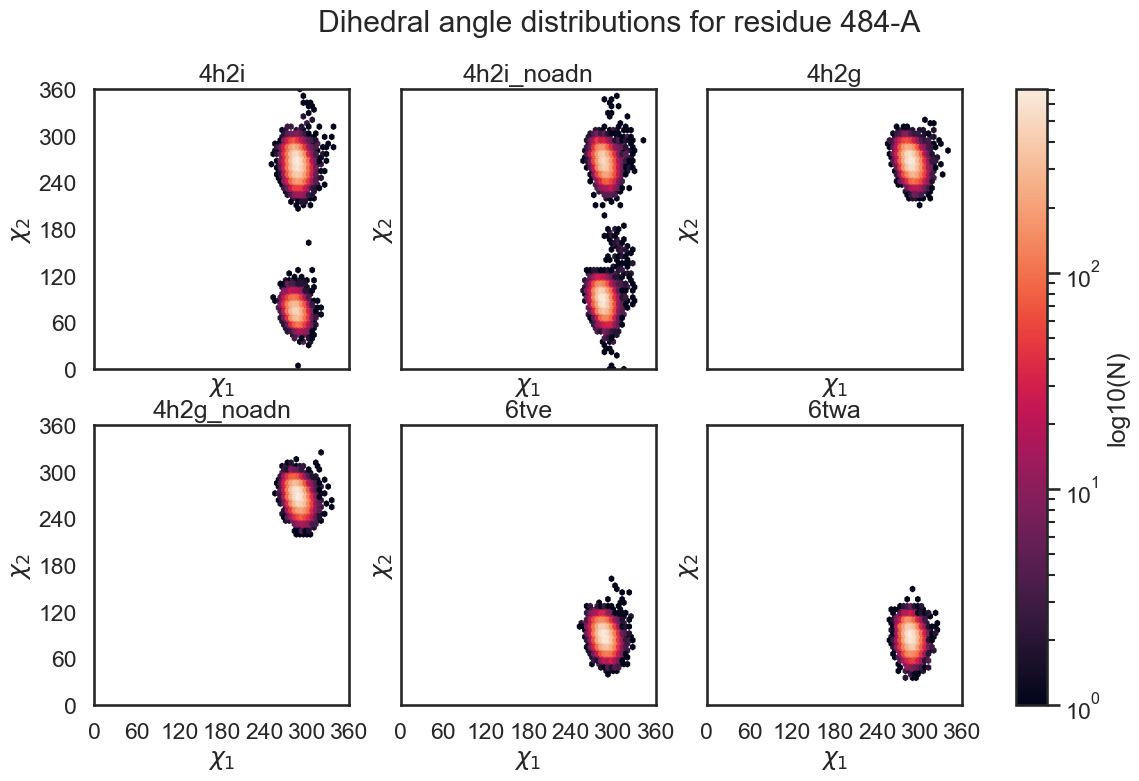

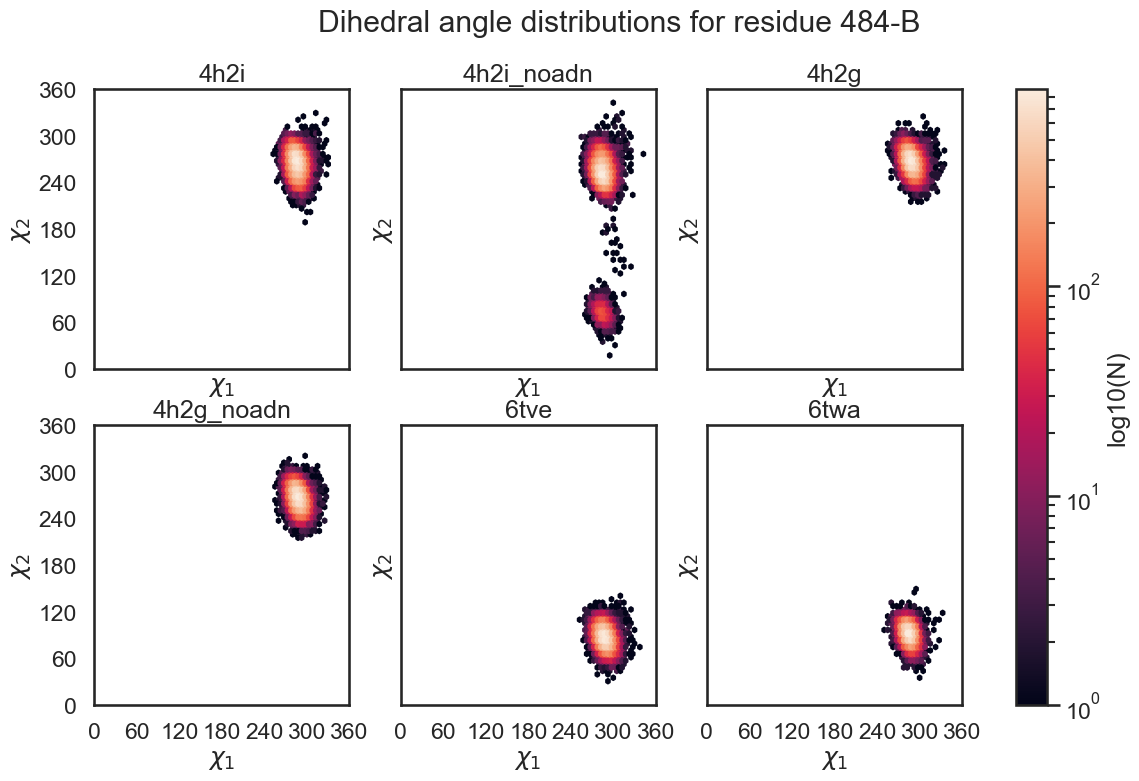

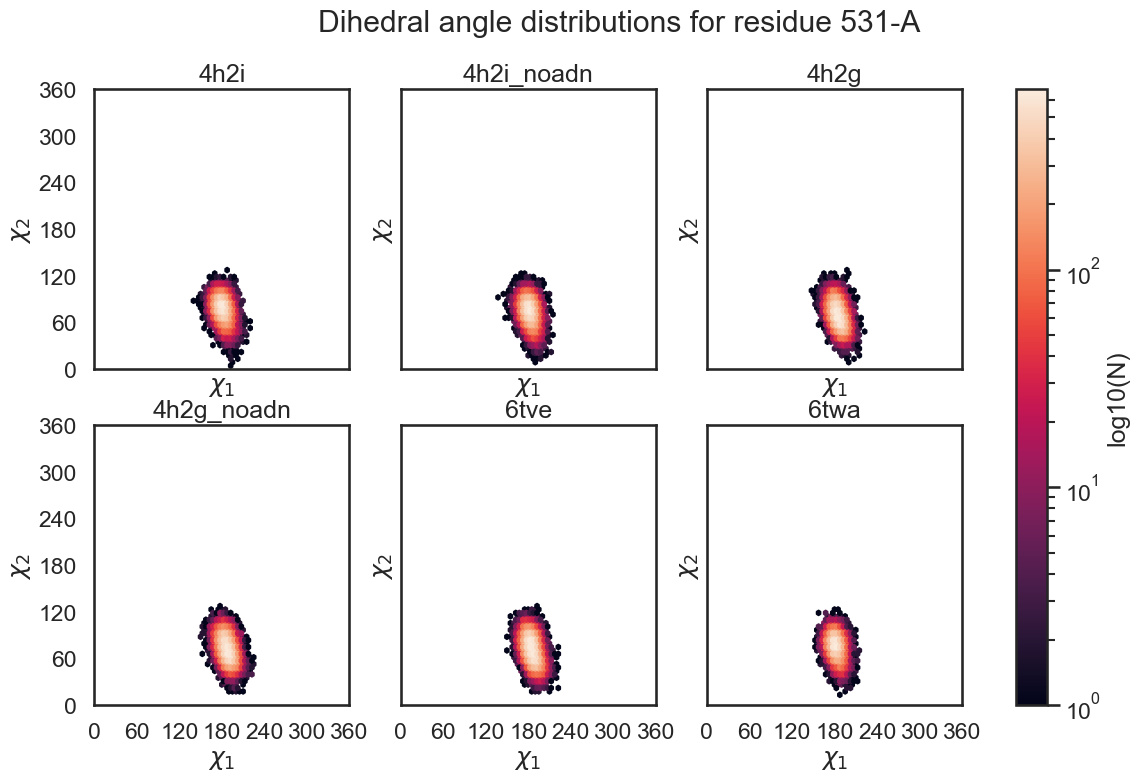

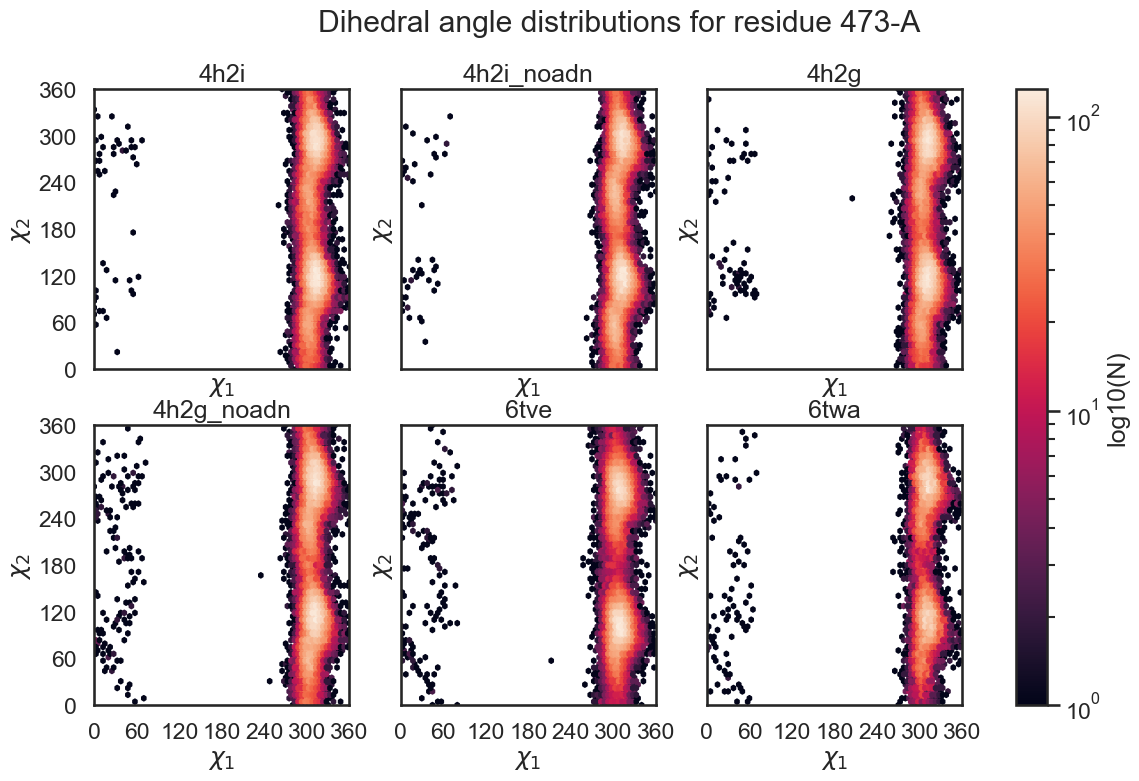

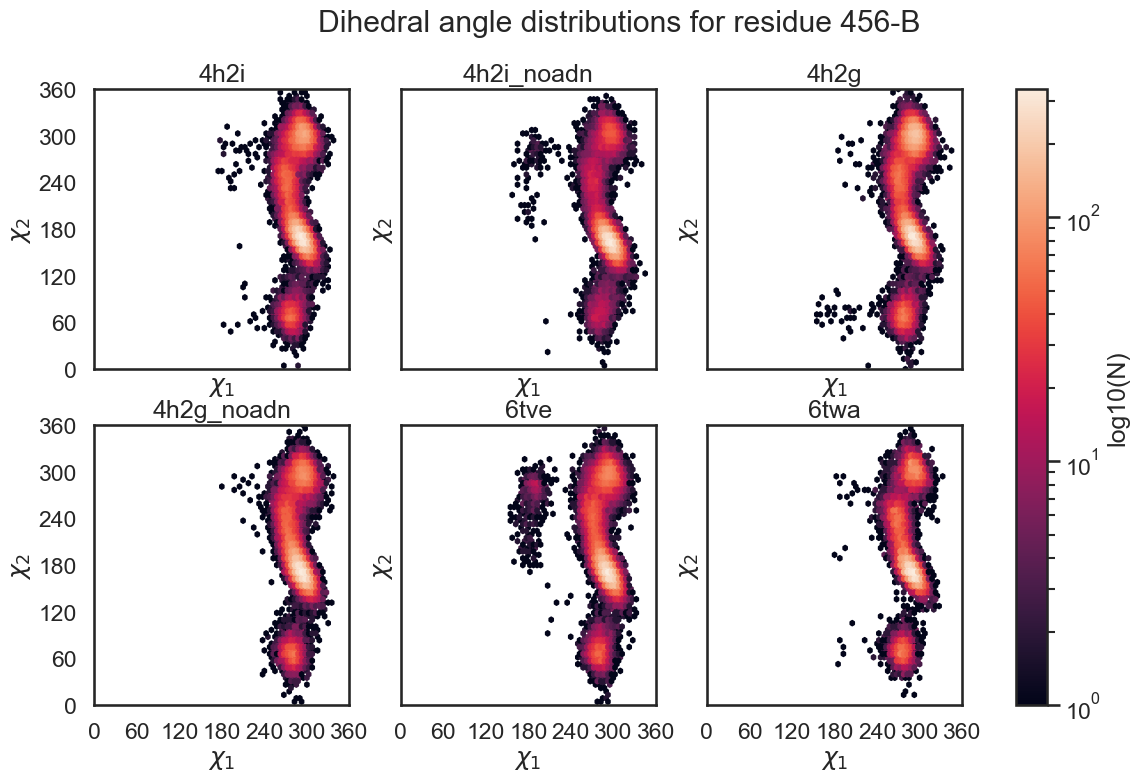

In [116]:
for residue in janin_results['4h2g'].keys():
    fig, axes = plt.subplots(
    2,
    3,
    sharex=True,
    sharey=True,
    figsize=(14,8)
    )

    axes = axes.flatten()

    for ax, name in zip(axes, janin_results.keys()):
    
        angles = janin_results[name][residue]
        chi1 = angles['chi1']
        chi2 = angles['chi2']

        hb = ax.hexbin(
            chi1,
            chi2,
            gridsize=72,
            bins="log",
            extent=(0,360,0,360)
        )

        ax.set_title(name)
        ax.set_xlim(0,360)
        ax.set_ylim(0,360)
        ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
        ax.set_yticks([0, 60, 120, 180, 240, 300, 360])
        ax.set_xlabel(r"$\chi_1$")
        ax.set_ylabel(r"$\chi_2$") 

    fig.colorbar(hb, ax=axes, label="log10(N)")
    fig.suptitle(f"Dihedral angle distributions for residue {residue}")  
    
    #plt.tight_layout()
    plt.show()

In [119]:
ROTAMERS = {
    "g+": 60,
    "t": 180,
    "g-": 300
}

def nearest_rotamer(angle):
    # periodic angular distance
    distances = {
        name: min(abs(angle-center), 360-abs(angle-center))
        for name, center in ROTAMERS.items()
    }
    return min(distances, key=distances.get)

def assign_state(chi1, chi2):
    r1 = nearest_rotamer(chi1)
    r2 = nearest_rotamer(chi2)
    return f"{r1}/{r2}"

angles = janin_results["4h2i"]["456-B"]

states = [
    assign_state(c1, c2)
    for c1, c2 in zip(angles["chi1"], angles["chi2"])
]

summary = (
    pd.Series(states)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(summary)

g-/t     61.42
g-/g-    31.17
g-/g+     7.31
t/g-      0.07
t/g+      0.02
t/t       0.01
Name: proportion, dtype: float64


The definition of the Janin function $\chi_1$ and $\chi_2$ angles for the residues follow the standard convention, and can be found [here](https://docs.mdanalysis.org/0.20.1/_modules/MDAnalysis/analysis/dihedrals.html). 

In the plots above, the distribution (`width` of 72 corresponding to the division of 360 degrees on the x-axis in 72 hexagons; 360 / 72 = 5 degrees, so each hexagon corresponds to a dihedral angle state encompassing 5 degrees of rotation) of rotamers are displayed. It can be seen that most residues follow the ['canonical' rotamer states](https://dunbrack.fccc.edu/lab/bbdep2010_tutorial).

Where:
- g(auche)-, t(trans), g(auche)+ are hihedral angles of 300, 180, 60 deg.

| Residue | Most important rotamers ($\chi_1 / \chi_2 $) | Notes |
| --- | --- | --- |
| Lys 471-A | t/t (75-80%), g-/t (10-15%), t/g+ (5%), g+/t (5%) | |
| Lys 547-B | g-/t (90%), g-/g- (5%), t/t (<5%) |
| Tyr 484-A | g-/g- (66%), g-/g+ (33%) | Only for `4h2i` with/without adn. All `4h2g` structures show 99% g-/g-, all `6tve`/`6twa` structures show 99% g-/g+ |
| Tyr 484-B | equal g-/g- and g-/g+ | All `4` structures show 95-99% g-/g-, all `6` structures show 95-99% g-/g+ |
| Tyr 531-A | >99% t/g+ | |
| Asp 473-A | g-/g- (35-40%), g-/g+ (30-35%), g-/t (20-30%) | more spread out, continuous transition of $\chi_2$ |
| His 456-B | g-/t (60%), g-/g+ (30%), g-/g+ (10%) | |


It should be noted that, even in cases where multiple probable rotamer states are observed over all trajectories, not every individual trajectory accesses each rotamer. This implies that to fully include all relevant rotamer states I need to include frames from more than one trajectory in my ensemble structures.

Additional Rotamers (`janin_analysis.ipynb`)

| Residue | Most important rotamers ($\chi_1$/$\chi_2$) | Notes |
| --- | --- | --- |
| Asp 366-A | g-/t (100%) | On plot, also g-/syn is present, but carboxylate is symmetrical |
| Glu 543-A | g-/t (90%), g+/t (5%) | | 
| Glu 543-B | g-/t (80-90%), g+/t (10-15%) | |
| Asp 473-B | g-/g- (35%), g-/g+ (30%), g-/t (30%) | more spread out, continuous transition of $\chi_2$ |
| Arg 545-A | g-/t (99%) | Arginine has longer side chain ($\chi_3, \chi_4$) which is not calculated |
| Arg 545-B | idem | idem |

## Dimensionality reduction / clustering of frames
Features to include:
- Pocket volume
- Pocket RMSD
- Residue dihedrals


In [145]:
descriptor_set_6tve = pd.DataFrame({
    "frame": [hull.frame for hull in allosteric_bindingsite_trajectories['6tve'].hulls],
    "pocket_volume": [hull.volume for hull in allosteric_bindingsite_trajectories['6tve'].hulls],
    # "pocket_rmsd": allosteric_bindingsite_trajectories['6tve'].rmsd.rmsd[:,2],

    "sin_chi1_471-A": np.sin(np.deg2rad(janin_results['6tve']['471-A']['chi1'])),
    "cos_chi1_471-A": np.cos(np.deg2rad(janin_results['6tve']['471-A']['chi1'])),
    "sin_chi2_471-A": np.sin(np.deg2rad(janin_results['6tve']['471-A']['chi2'])),
    "cos_chi2_471-A": np.cos(np.deg2rad(janin_results['6tve']['471-A']['chi2'])),

    "sin_chi1_547-B": np.sin(np.deg2rad(janin_results['6tve']['547-B']['chi1'])),
    "cos_chi1_547-B": np.cos(np.deg2rad(janin_results['6tve']['547-B']['chi1'])),
    "sin_chi2_547-B": np.sin(np.deg2rad(janin_results['6tve']['547-B']['chi2'])),
    "cos_chi2_547-B": np.cos(np.deg2rad(janin_results['6tve']['547-B']['chi2'])),

    "sin_chi1_484-A": np.sin(np.deg2rad(janin_results['6tve']['484-A']['chi1'])),
    "cos_chi1_484-A": np.cos(np.deg2rad(janin_results['6tve']['484-A']['chi1'])),
    "sin_chi2_484-A": np.sin(np.deg2rad(janin_results['6tve']['484-A']['chi2'])),
    "cos_chi2_484-A": np.cos(np.deg2rad(janin_results['6tve']['484-A']['chi2'])),

    "sin_chi1_484-B": np.sin(np.deg2rad(janin_results['6tve']['484-B']['chi1'])),
    "cos_chi1_484-B": np.cos(np.deg2rad(janin_results['6tve']['484-B']['chi1'])),
    "sin_chi2_484-B": np.sin(np.deg2rad(janin_results['6tve']['484-B']['chi2'])),
    "cos_chi2_484-B": np.cos(np.deg2rad(janin_results['6tve']['484-B']['chi2'])),

    "sin_chi1_473-A": np.sin(np.deg2rad(janin_results['6tve']['473-A']['chi1'])),
    "cos_chi1_473-A": np.cos(np.deg2rad(janin_results['6tve']['473-A']['chi1'])),
    "sin_chi2_473-A": np.sin(np.deg2rad(janin_results['6tve']['473-A']['chi2'])),
    "cos_chi2_473-A": np.cos(np.deg2rad(janin_results['6tve']['473-A']['chi2'])),

    "sin_chi1_456-B": np.sin(np.deg2rad(janin_results['6tve']['456-B']['chi1'])),
    "cos_chi1_456-B": np.cos(np.deg2rad(janin_results['6tve']['456-B']['chi1'])),
    "sin_chi2_456-B": np.sin(np.deg2rad(janin_results['6tve']['456-B']['chi2'])),
    "cos_chi2_456-B": np.cos(np.deg2rad(janin_results['6tve']['456-B']['chi2'])),


})

X_6tve = descriptor_set_6tve.drop(columns=['frame']).values
X_6tve_scaled = StandardScaler().fit_transform(X_6tve)

feat_cols = [f'feature'+str(i) for i in range(X_6tve_scaled.shape[1])]
X_6tve_scaled_df = pd.DataFrame(X_6tve_scaled, columns=feat_cols)
X_6tve_scaled_df.head()

,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,...,feature15,feature16,feature17,feature18,feature19,feature20,feature21,feature22,feature23,feature24
0,-1.396097,0.348978,-0.574755,-0.270880,-0.275646,-0.259051,0.171394,-0.948640,-0.114235,-0.017013,...,-3.615524,2.247787,-0.208496,-0.017463,-1.033495,1.162397,-0.736354,-1.285542,-0.455118,-0.641232
1,-1.061557,0.469472,-0.592424,-1.218608,-0.128425,0.052299,0.560331,0.996715,-0.204672,0.845825,...,0.322032,0.510628,1.228673,1.338384,-1.161520,0.658088,-0.473600,-0.212682,-0.277174,-0.704786
2,0.337089,0.238068,-0.554064,-0.158707,-0.275233,-0.425593,-0.108503,1.258207,-0.146300,1.903414,...,0.104893,0.702067,0.060216,0.303301,-0.936555,1.398563,-0.521619,-0.305985,-1.392850,0.333131
3,-0.398720,0.657579,-0.610284,1.282034,0.074047,-0.155281,0.315498,-0.293968,-0.247501,-0.514325,...,0.318546,0.514084,-0.853031,-1.007596,-0.772461,1.681216,-0.189645,0.211874,0.511089,-0.753080
4,0.384787,-0.266250,-0.401771,0.831950,-0.107131,-0.675501,-0.887433,0.129158,-0.277315,-0.378863,...,-1.139364,1.409653,-0.886794,-1.072039,-0.856148,1.551126,0.162983,0.591820,0.461517,-0.760663


In [127]:
descriptor_set_4h2i = pd.DataFrame({
    "frame": [hull.frame for hull in allosteric_bindingsite_trajectories['4h2i'].hulls],
    "pocket_volume": [hull.volume for hull in allosteric_bindingsite_trajectories['4h2i'].hulls],
    "pocket_rmsd": allosteric_bindingsite_trajectories['4h2i'].rmsd.rmsd[:,2],

    "sin_chi1_471-A": np.sin(np.deg2rad(janin_results['4h2i']['471-A']['chi1'])),
    "cos_chi1_471-A": np.cos(np.deg2rad(janin_results['4h2i']['471-A']['chi1'])),
    "sin_chi2_471-A": np.sin(np.deg2rad(janin_results['4h2i']['471-A']['chi2'])),
    "cos_chi2_471-A": np.cos(np.deg2rad(janin_results['4h2i']['471-A']['chi2'])),

    "sin_chi1_547-B": np.sin(np.deg2rad(janin_results['4h2i']['547-B']['chi1'])),
    "cos_chi1_547-B": np.cos(np.deg2rad(janin_results['4h2i']['547-B']['chi1'])),
    "sin_chi2_547-B": np.sin(np.deg2rad(janin_results['4h2i']['547-B']['chi2'])),
    "cos_chi2_547-B": np.cos(np.deg2rad(janin_results['4h2i']['547-B']['chi2'])),

    "sin_chi1_484-A": np.sin(np.deg2rad(janin_results['4h2i']['484-A']['chi1'])),
    "cos_chi1_484-A": np.cos(np.deg2rad(janin_results['4h2i']['484-A']['chi1'])),
    "sin_chi2_484-A": np.sin(np.deg2rad(janin_results['4h2i']['484-A']['chi2'])),
    "cos_chi2_484-A": np.cos(np.deg2rad(janin_results['4h2i']['484-A']['chi2'])),

    "sin_chi1_484-B": np.sin(np.deg2rad(janin_results['4h2i']['484-B']['chi1'])),
    "cos_chi1_484-B": np.cos(np.deg2rad(janin_results['4h2i']['484-B']['chi1'])),
    "sin_chi2_484-B": np.sin(np.deg2rad(janin_results['4h2i']['484-B']['chi2'])),
    "cos_chi2_484-B": np.cos(np.deg2rad(janin_results['4h2i']['484-B']['chi2'])),

    "sin_chi1_473-A": np.sin(np.deg2rad(janin_results['4h2i']['473-A']['chi1'])),
    "cos_chi1_473-A": np.cos(np.deg2rad(janin_results['4h2i']['473-A']['chi1'])),
    "sin_chi2_473-A": np.sin(np.deg2rad(janin_results['4h2i']['473-A']['chi2'])),
    "cos_chi2_473-A": np.cos(np.deg2rad(janin_results['4h2i']['473-A']['chi2'])),

    "sin_chi1_456-B": np.sin(np.deg2rad(janin_results['4h2i']['456-B']['chi1'])),
    "cos_chi1_456-B": np.cos(np.deg2rad(janin_results['4h2i']['456-B']['chi1'])),
    "sin_chi2_456-B": np.sin(np.deg2rad(janin_results['4h2i']['456-B']['chi2'])),
    "cos_chi2_456-B": np.cos(np.deg2rad(janin_results['4h2i']['456-B']['chi2'])),


})

X_4h2i = descriptor_set_4h2i.drop(columns=['frame']).values
X_4h2i_scaled = StandardScaler().fit_transform(X_4h2i)

feat_cols = [f'feature'+str(i) for i in range(X_4h2i_scaled.shape[1])]
X_4h2i_scaled_df = pd.DataFrame(X_4h2i_scaled, columns=feat_cols)
X_4h2i_scaled_df.head()

,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,...,feature16,feature17,feature18,feature19,feature20,feature21,feature22,feature23,feature24,feature25
0,0.063918,-7.053433,-0.544878,-0.231471,0.144080,-0.258153,0.080325,0.573447,-0.566418,-0.222157,...,-0.454704,-0.271372,0.928814,1.010833,-1.035701,1.005423,-0.219980,0.137887,0.250479,-0.850624
1,1.055698,-2.508812,0.204819,-0.480503,-1.327972,-0.097241,-0.689707,-0.752448,-0.305214,-0.264808,...,0.133376,-0.816531,-0.801833,-0.783330,-1.107706,0.855579,1.309907,1.171653,0.925839,-0.722787
2,0.111100,-2.745759,-0.499605,-0.252181,0.385437,-0.223288,0.543833,0.959290,0.097870,-0.297867,...,-0.518447,0.908564,0.991518,1.055764,-0.829750,1.302227,-0.740279,-0.474657,0.534400,-0.829491
3,0.199942,-2.765061,0.007537,-0.432653,-0.799139,-0.229997,0.439103,0.882016,0.531182,-0.290187,...,0.244340,-0.891936,1.617014,1.453778,-1.181795,0.648504,0.525058,0.717769,0.778629,-0.774259
4,0.466054,-2.918849,0.529914,-0.535476,0.232226,-0.247438,0.171403,0.659311,0.245481,-0.300259,...,-0.690051,0.344531,-0.400478,-0.238927,-1.243958,0.363295,-0.867856,-0.697306,0.038874,-0.837405


array([[<Axes: title={'center': 'frame'}>,
        <Axes: title={'center': 'pocket_volume'}>,
        <Axes: title={'center': 'sin_chi1_471-A'}>,
        <Axes: title={'center': 'cos_chi1_471-A'}>,
        <Axes: title={'center': 'sin_chi2_471-A'}>],
       [<Axes: title={'center': 'cos_chi2_471-A'}>,
        <Axes: title={'center': 'sin_chi1_547-B'}>,
        <Axes: title={'center': 'cos_chi1_547-B'}>,
        <Axes: title={'center': 'sin_chi2_547-B'}>,
        <Axes: title={'center': 'cos_chi2_547-B'}>],
       [<Axes: title={'center': 'sin_chi1_484-A'}>,
        <Axes: title={'center': 'cos_chi1_484-A'}>,
        <Axes: title={'center': 'sin_chi2_484-A'}>,
        <Axes: title={'center': 'cos_chi2_484-A'}>,
        <Axes: title={'center': 'sin_chi1_484-B'}>],
       [<Axes: title={'center': 'cos_chi1_484-B'}>,
        <Axes: title={'center': 'sin_chi2_484-B'}>,
        <Axes: title={'center': 'cos_chi2_484-B'}>,
        <Axes: title={'center': 'sin_chi1_473-A'}>,
        <Axes: titl

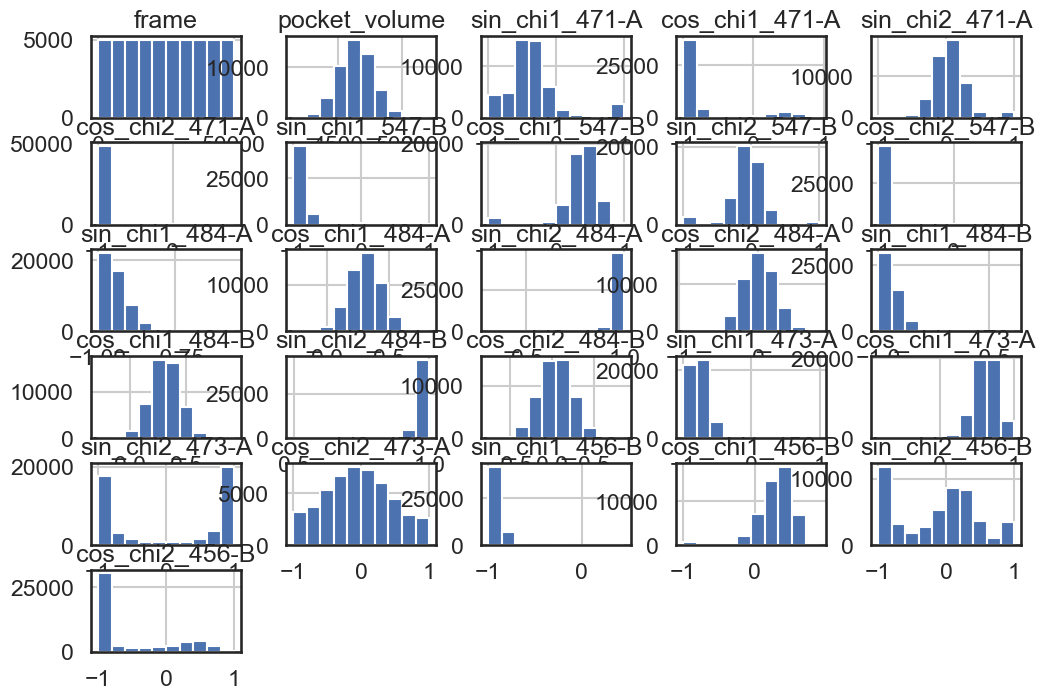

In [146]:
descriptor_set_6tve.hist(figsize=(12,8))
# descriptor_set.corr()

## T-SNE


In [138]:
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate='auto',
    init='pca',
    random_state=42

)

X_tsne = tsne.fit_transform(X_6tve_scaled)

## Pairwise RMSD of binding site residues

In [ ]:
# https://www.blopig.com/blog/2025/08/taming-the-trajectory-beast-a-simpler-way-to-sample-your-md-simulations/

# matrix_4h2i_bindingsite = diffusionmap.DistanceMatrix(allosteric_bindingsite_trajectories['4h2i'].residue_atoms)
# matrix_4h2i_bindingsite.run(start=1, stop=50000, step=1000)

In [41]:
# Load from .npy binaries
# matrix_4h2i_bindingsite_1000 = np.load("./data/pairwise_rmsd/matrix_4h2i_bindingsite_1000.npy")
# matrix_4h2i_bindingsite_200 = np.load("./data/pairwise_rmsd/matrix_4h2i_bindingsite_200.npy")
# matrix_4h2i_bindingsite_100 = np.load("./data/pairwise_rmsd/matrix_4h2i_bindingsite_100.npy")
# matrix_4h2i_bindingsite_50 = np.load("./data/pairwise_rmsd/matrix_4h2i_bindingsite_50.npy")
matrix_4h2i_bindingsite_10 = np.load("./data/pairwise_rmsd/matrix_4h2i_bindingsite_10.npy")

# matrix_6tve_bindingsite_1000 = np.load("./data/pairwise_rmsd/matrix_6tve_bindingsite_1000.npy")
# matrix_6tve_bindingsite_200 = np.load("./data/pairwise_rmsd/matrix_6tve_bindingsite_200.npy")
# matrix_6tve_bindingsite_100 = np.load("./data/pairwise_rmsd/matrix_6tve_bindingsite_100.npy")
# matrix_6tve_bindingsite_50 = np.load("./data/pairwise_rmsd/matrix_6tve_bindingsite_50.npy")
matrix_6tve_bindingsite_10 = np.load("./data/pairwise_rmsd/matrix_6tve_bindingsite_10.npy")


## 4h2i

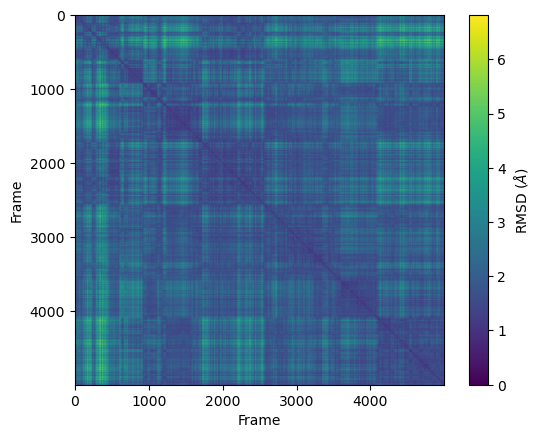

In [43]:
plt.imshow(matrix_4h2i_bindingsite_10)
plt.xlabel("Frame")
plt.ylabel("Frame")
plt.colorbar(label=r"RMSD ($\AA$)")


In [58]:
D_4h2i_10 = matrix_4h2i_bindingsite_10
D_condensed_4h2i_10 = squareform(D_4h2i_10)
Z_4h2i = cluster.hierarchy.linkage(D_condensed_4h2i_10, method='complete')

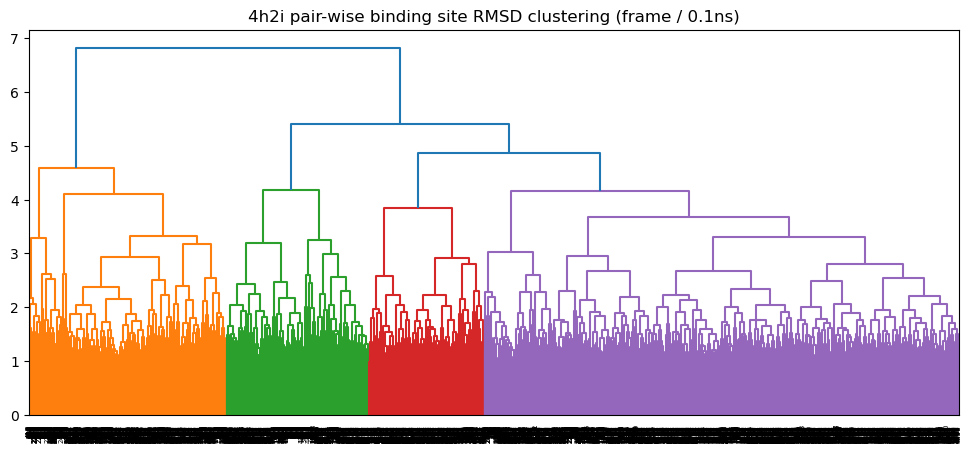

In [59]:
plt.figure(figsize=(12,5))
plt.title("4h2i pair-wise binding site RMSD clustering (frame / 0.1ns)")
cluster.hierarchy.dendrogram(Z_4h2i)
plt.show()

In [74]:
labels_4h2i = cluster.hierarchy.fcluster(Z_4h2i, t=4, criterion='maxclust')
print(labels_4h2i[0:100])
print(len(labels_4h2i))

[4 4 4 4 4 4 4 4 2 4 4 4 4 4 4 4 4 4 4 4 1 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 1 4 1 4 4 4 4 4 4 4 4 4 1 4 4 4 4 4 4 1 1 1 1 4 4 4 4 4 4 4 4 4 4 1 4 4 4
 1 4 4 4 4 4 4 4 4 4 4 4 4 4 1 4 4 4 4 4 4 4 4 4 4 1]
5000


In [75]:
stepsize = 10 # 50 * 10.0 ps = 500 ps = 10 ns 
frames = np.arange(1, 50_000, stepsize)

# Create dict with real trajectory frame indices in each cluster
clusters_4h2i = {}

for cluster_id in np.unique(labels_4h2i):
    clustered_indices = np.where(labels_4h2i == cluster_id)[0]

    original_frames = frames[clustered_indices]

    clusters_4h2i[f"cluster_{cluster_id}"] = original_frames

# Pick representative for each cluster by picking medoid frame:
# medoid: the frame with the lowest average RMSD to all other frames in cluster
representatives_4h2i = {}

for cluster_id, frames in clusters_4h2i.items():
    cluster_matrix = D[np.ix_(frames // stepsize, frames // stepsize)]

    mean_distances = cluster_matrix.mean(axis=1)
    medoid_idx = np.argmin(mean_distances)
    representative_frame = frames[medoid_idx]

    representatives_4h2i[cluster_id] = representative_frame

In [76]:
representatives_4h2i

{'cluster_1': np.int64(22881),
 'cluster_2': np.int64(26321),
 'cluster_3': np.int64(46531),
 'cluster_4': np.int64(24281)}

## 6tve

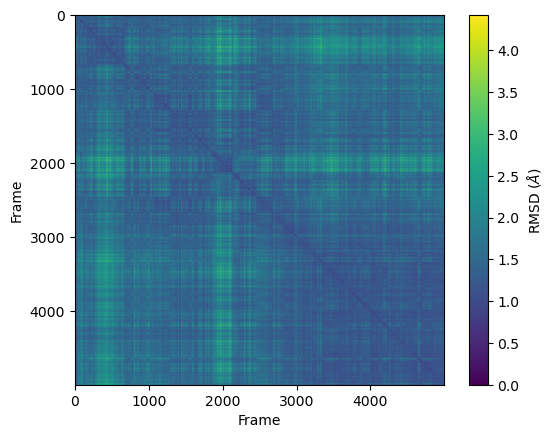

In [ ]:
plt.imshow(matrix_6tve_bindingsite_10)
plt.xlabel("Frame")
plt.ylabel("Frame")
plt.colorbar(label=r"RMSD ($\AA$)")


In [65]:
D_6tve_10 = matrix_6tve_bindingsite_10
D_condensed_6tve_10 = squareform(D_6tve_10)
Z_6tve = cluster.hierarchy.linkage(D_condensed_6tve_10, method='complete')

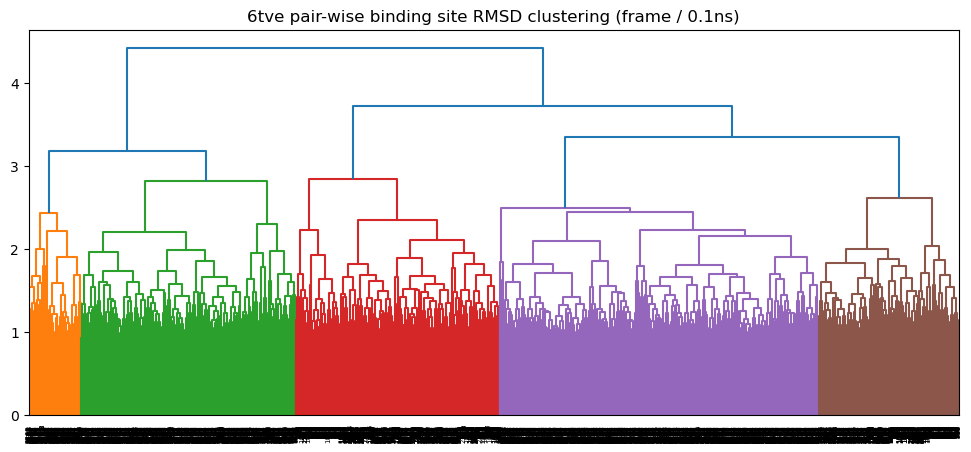

In [66]:
plt.figure(figsize=(12,5))
plt.title("6tve pair-wise binding site RMSD clustering (frame / 0.1ns)")
cluster.hierarchy.dendrogram(Z_6tve)
plt.show()

In [77]:
labels_6tve = cluster.hierarchy.fcluster(Z_6tve, t=4, criterion='maxclust')
print(labels_6tve[0:100])
print(len(labels_6tve))

[1 1 1 1 2 2 2 2 2 2 2 2 1 1 2 1 1 1 1 2 4 4 4 2 2 3 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 4 2 2 2 2 2 2 4 4 4 4 4 4 4 4 4 4 2 2 2 2 2 2 4 4 4 4 1 2
 2 2 2 1 1 2 2 2 1 4 2 1 1 2 4 2 1 2 2 2 1 2 2 2 2 2]
5000


In [78]:
stepsize = 10 # 50 * 10.0 ps = 500 ps = 10 ns 
frames = np.arange(1, 50_000, stepsize)

# Create dict with real trajectory frame indices in each cluster
clusters_6tve = {}

for cluster_id in np.unique(labels_6tve):
    clustered_indices = np.where(labels_6tve == cluster_id)[0]

    original_frames = frames[clustered_indices]

    clusters_6tve[f"cluster_{cluster_id}"] = original_frames

# Pick representative for each cluster by picking medoid frame:
# medoid: the frame with the lowest average RMSD to all other frames in cluster
representatives_6tve = {}

for cluster_id, frames in clusters_6tve.items():
    cluster_matrix = D[np.ix_(frames // stepsize, frames // stepsize)]

    mean_distances = cluster_matrix.mean(axis=1)
    medoid_idx = np.argmin(mean_distances)
    representative_frame = frames[medoid_idx]

    representatives_6tve[cluster_id] = representative_frame

In [79]:
representatives_6tve

{'cluster_1': np.int64(19121),
 'cluster_2': np.int64(16731),
 'cluster_3': np.int64(48731),
 'cluster_4': np.int64(6031)}

In [80]:
for cluster in representatives_4h2i.keys():
    allosteric_bindingsite_trajectories['4h2i'].write_system_frame_pdb(frame_index=representatives_4h2i[cluster], 
                                                                       output_path=Path(f"./data/4h2i_clusters/4h2i_medoid_{cluster}.pdb"))

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1336: UserWarning: Found missing chainIDs. Corresponding atoms will use value of 'X'
  warnings.warn(


Wrote system frame 22881 to PDB: data/4h2i_clusters/4h2i_medoid_cluster_1.pdb
Wrote hull PDB to: data/4h2i_clusters/hull_frame_22881.pdb
Wrote PyMol view script to data/4h2i_clusters/view_system_frame22881.pml
Wrote system frame 26321 to PDB: data/4h2i_clusters/4h2i_medoid_cluster_2.pdb
Wrote hull PDB to: data/4h2i_clusters/hull_frame_26321.pdb
Wrote PyMol view script to data/4h2i_clusters/view_system_frame26321.pml
Wrote system frame 46531 to PDB: data/4h2i_clusters/4h2i_medoid_cluster_3.pdb
Wrote hull PDB to: data/4h2i_clusters/hull_frame_46531.pdb
Wrote PyMol view script to data/4h2i_clusters/view_system_frame46531.pml
Wrote system frame 24281 to PDB: data/4h2i_clusters/4h2i_medoid_cluster_4.pdb
Wrote hull PDB to: data/4h2i_clusters/hull_frame_24281.pdb
Wrote PyMol view script to data/4h2i_clusters/view_system_frame24281.pml


In [81]:
for cluster in representatives_6tve.keys():
    allosteric_bindingsite_trajectories['6tve'].write_system_frame_pdb(frame_index=representatives_6tve[cluster], 
                                                                       output_path=Path(f"./data/6tve_clusters/6tve_medoid_{cluster}.pdb"))

Wrote system frame 19121 to PDB: data/6tve_clusters/6tve_medoid_cluster_1.pdb


100%|██████████| 50006/50006 [01:28<00:00, 563.14it/s]


Wrote hull PDB to: data/6tve_clusters/hull_frame_19121.pdb
Wrote PyMol view script to data/6tve_clusters/view_system_frame19121.pml
Wrote system frame 16731 to PDB: data/6tve_clusters/6tve_medoid_cluster_2.pdb
Wrote hull PDB to: data/6tve_clusters/hull_frame_16731.pdb
Wrote PyMol view script to data/6tve_clusters/view_system_frame16731.pml
Wrote system frame 48731 to PDB: data/6tve_clusters/6tve_medoid_cluster_3.pdb
Wrote hull PDB to: data/6tve_clusters/hull_frame_48731.pdb
Wrote PyMol view script to data/6tve_clusters/view_system_frame48731.pml
Wrote system frame 6031 to PDB: data/6tve_clusters/6tve_medoid_cluster_4.pdb
Wrote hull PDB to: data/6tve_clusters/hull_frame_6031.pdb
Wrote PyMol view script to data/6tve_clusters/view_system_frame6031.pml
